In [2]:
import itertools as it
from collections import deque
import copy

import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import OneClassSVM
from sklearn.inspection import DecisionBoundaryDisplay
from river import tree

# Import from your ht2d package
from ht2d.distributions import GaussianMixture, DriftingMixtureStream
from ht2d.detectors import (
    NoDriftDetector,
    ThresholdDriftDetector,
    ZTestDriftDetector,
)
from ht2d.models import (
    to_array,
    HoeffdingTreeClassifier,
    GaussianNBClassifier,
    PAClassifier,
    SklearnLinearSVCClassifier,
    SklearnRBFSVCClassifier,
    AdaptiveRandomForestClassifier,
    LogisticRegressionClassifier,
    SklearnMLPClassifier,
)


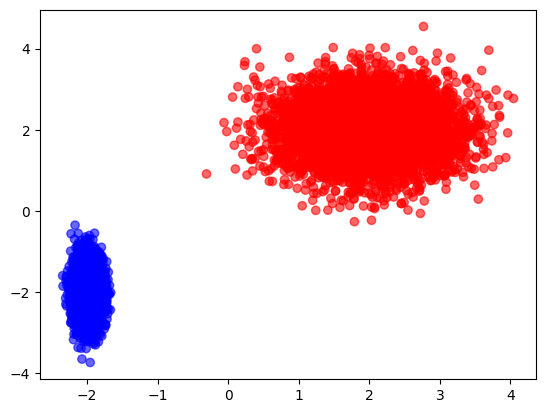

empirical outlier fraction: 0.0932


In [3]:
# Simple mixture to visualize and estimate OCC outlier fraction

rng = np.random.default_rng(42)

d = GaussianMixture(
    mu=[[-2, -2], [2, 2]],
    sigma=[[0.01, 0.2], [0.4, 0.4]],
    class_=[0, 1],
    p=[0.5, 0.5],
    n=10_000,
    rng=rng,
)

# Plot a few samples
x_1, x_2, c = [], [], []
for x, y in it.islice(d.sample(), 10_000):
    x_1.append(x["x_0"])
    x_2.append(x["x_1"])
    c.append(y)

fig, ax = plt.subplots()
ax.scatter(x_1, x_2, c=c, cmap="bwr", alpha=0.6)
plt.show()

# Train OCC on a small training set
rng = np.random.default_rng(123)
d_train = GaussianMixture(
    mu=d.mu, sigma=d.sigma, class_=d.class_, p=d.p, n=1_000, rng=rng
)
X_train = np.array([[x["x_0"], x["x_1"]] for x, y in it.islice(d_train.sample(), 250)])
occ = OneClassSVM(kernel="rbf", gamma=0.5, nu=0.1).fit(X_train)

# Estimate empirical outlier fraction
d_test = GaussianMixture(
    mu=d.mu, sigma=d.sigma, class_=d.class_, p=d.p, n=10_000, rng=rng
)
outlier = occ.predict(
    np.array([[x["x_0"], x["x_1"]] for x, y in it.islice(d_test.sample(), 10_000)])
)
outlier_rate = (outlier == -1).mean()
print(f"empirical outlier fraction: {outlier_rate:.4f}")


In [4]:
def stream_factory(seed: int):
    rng = np.random.default_rng(seed)
    g1 = GaussianMixture(
        mu=[[0, 0], [1, 1]],
        sigma=[[0.2, 0.2], [0.2, 0.2]],
        class_=[0, 1],
        p=[0.5, 0.5],
        n=80_000,
        rng=rng,
    )
    g2 = GaussianMixture(
        mu=[[0, 1], [0, 0]],
        sigma=[[0.4, 0.4], [0.4, 0.4]],
        class_=[0, 1],
        p=[0.5, 0.5],
        n=80_000,
        rng=rng,
    )
    g3 = GaussianMixture(
        mu=[[0, 0], [1, 1]],
        sigma=[[0.2, 0.2], [0.2, 0.2]],
        class_=[0, 1],
        p=[0.5, 0.5],
        n=80_000,
        rng=rng,
    )
    mixtures = [g1, g2, g3]
    drift_points = [(4_000, 4_800), (6_000, 6_800)]
    return DriftingMixtureStream(mixtures=mixtures, drift_points=drift_points, rng=rng)


def stream_factory_2(seed: int):
    rng = np.random.default_rng(seed)
    g1 = GaussianMixture(
        mu=[[0, -1], [1, 1]],
        sigma=[[0.01, 0.2], [0.2, 0.01]],
        class_=[0, 1],
        p=[0.5, 0.5],
        n=80_000,
        rng=rng,
    )
    g2 = GaussianMixture(
        mu=[[0, -1], [-1, -3]],
        sigma=[[0.01, 0.2], [0.2, 0.01]],
        class_=[0, 1],
        p=[0.5, 0.5],
        n=80_000,
        rng=rng,
    )
    g3 = GaussianMixture(
        mu=[[0, -1], [1, 1]],
        sigma=[[0.01, 0.2], [0.2, 0.01]],
        class_=[0, 1],
        p=[0.5, 0.5],
        n=80_000,
        rng=rng,
    )
    mixtures = [g1, g2, g3]
    drift_points = [(2_000, 3_000), (5_000, 6_000)]
    return DriftingMixtureStream(mixtures=mixtures, drift_points=drift_points, rng=rng)


def stream_factory_2_new(seed: int):
    rng = np.random.default_rng(seed)
    g1 = GaussianMixture(
        mu=[[0, -1], [1, 1]],
        sigma=[[0.01, 0.2], [0.2, 0.01]],
        class_=[0, 1],
        p=[0.5, 0.5],
        n=80_000,
        rng=rng,
    )
    g2 = GaussianMixture(
        mu=[[0, -1], [-1, -2]],
        sigma=[[0.01, 0.2], [0.2, 0.01]],
        class_=[0, 1],
        p=[0.5, 0.5],
        n=80_000,
        rng=rng,
    )
    g3 = GaussianMixture(
        mu=[[0, -1], [1, 1]],
        sigma=[[0.01, 0.2], [0.2, 0.01]],
        class_=[0, 1],
        p=[0.5, 0.5],
        n=80_000,
        rng=rng,
    )
    mixtures = [g1, g2, g3]
    drift_points = [(2_000, 3_000), (5_000, 6_000)]
    return DriftingMixtureStream(mixtures=mixtures, drift_points=drift_points, rng=rng)


def stream_factory_3(seed: int):
    rng = np.random.default_rng(seed)
    g1 = GaussianMixture(
        mu=[[0, 1], [0, 0]],
        sigma=[[0.4, 0.4], [0.4, 0.4]],
        class_=[0, 1],
        p=[0.5, 0.5],
        n=80_000,
        rng=rng,
    )
    g2 = GaussianMixture(
        mu=[[0, 0], [1, 1]],
        sigma=[[0.2, 0.2], [0.2, 0.2]],
        class_=[0, 1],
        p=[0.5, 0.5],
        n=80_000,
        rng=rng,
    )
    g3 = GaussianMixture(
        mu=[[0, 1], [0, 0]],
        sigma=[[0.4, 0.4], [0.4, 0.4]],
        class_=[0, 1],
        p=[0.5, 0.5],
        n=80_000,
        rng=rng,
    )
    mixtures = [g1, g2, g3]
    drift_points = [(2_000, 3_000), (5_000, 6_000)]
    return DriftingMixtureStream(mixtures=mixtures, drift_points=drift_points, rng=rng)

#sudden drift
def stream_factory_sudden(seed: int):
    rng = np.random.default_rng(seed)

    # Pre-drift mixture (concept A)
    g1 = GaussianMixture(
        mu=[[0, 0], [1, 1]],
        sigma=[[0.2, 0.2], [0.2, 0.2]],
        class_=[0, 1],
        p=[0.5, 0.5],
        n=80_000,
        rng=rng,
    )

    # Post-drift mixture (concept B), clearly different
    g2 = GaussianMixture(
        mu=[[0, 2], [2, 0]],
        sigma=[[0.2, 0.2], [0.2, 0.2]],
        class_=[0, 1],
        p=[0.5, 0.5],
        n=80_000,
        rng=rng,
    )

    g3 = GaussianMixture(
        mu=[[0, 0], [1, 1]],
        sigma=[[0.2, 0.2], [0.2, 0.2]],
        class_=[0, 1],
        p=[0.5, 0.5],
        n=80_000,
        rng=rng,
    )

    mixtures = [g1, g2, g3]

    #  Abrupt drift at t = 4000 (no interval, just a point)
    drift_points = [4_000,6000]  # int -> sudden drift

    return DriftingMixtureStream(
        mixtures=mixtures,
        drift_points=drift_points,
        rng=rng,
    )




In [5]:
keep_fraction = 0.1  # same as in the original notebook


def accumulate_examples(stream, n, x_window, y_window, keep_fraction=0.0):
    """Refill sliding windows from a stream, keeping a fraction of recent data."""
    if not (0.0 <= keep_fraction <= 1.0):
        raise ValueError("keep_fraction must be between 0.0 and 1.0")

    m = int(len(x_window) * keep_fraction)

    if m > 0:
        x_recent = list(it.islice(x_window, len(x_window) - m, None))
        y_recent = list(it.islice(y_window, len(y_window) - m, None))
    else:
        x_recent, y_recent = [], []

    x_window.clear()
    y_window.clear()
    x_window.extend(x_recent)
    y_window.extend(y_recent)

    n_new = n - len(x_window)
    for x, y in it.islice(stream.sample(), n_new):
        x_window.append(to_array(x))
        y_window.append(y)

def generate_figure(ax, accuracy, detected_drifts, stream, detector):
    num_drifts = []
    for a, d in zip(accuracy, detected_drifts):
        num_drifts.append(len(d))
        u, v = zip(*a)
        ax.step(u, v, color="blue", alpha=0.3)
        if d:
            u, v = zip(*d)
            ax.scatter(u, v, color="red", label="Detected drifts", s=10)

    # visualize true drift points (both gradual and sudden)
    for drift in stream.drift_points:
        if isinstance(drift, int):
            # sudden drift: just a vertical line at the drift time
            ax.axvline(drift, color="gray", linewidth=1.5, alpha=1.0)
        else:
            # gradual drift: (start, end)
            start_drift, end_drift = drift
            ax.axvspan(start_drift, end_drift, color="gray", alpha=0.2)
            ax.axvline(start_drift, color="gray", linewidth=1.5, alpha=1.0)
            ax.axvline(end_drift, color="gray", linewidth=1.5, alpha=1.0)


    message = "Detected drifts: "
    message += f"{np.mean(num_drifts):.2f} ± {np.std(num_drifts):.2f}"
    ax.set_title(message)
    ax.set_xlabel(detector.message())

#####################################
def snr(detected_drifts, drift_points, tol=0,return_counts=False):
    """
    SNR = TP / FP

    TP: detections that happen during a true drift region.
        - gradual drift: inside (start,end) or within tol after end
        - sudden drift: within tol of the drift time
    FP: detections outside all true drift regions

    detected_drifts: list of (t_det, acc_at_t)
    drift_points: list of ints (sudden) or tuples (start,end) (gradual)
    tol: tolerance window (recommend tol=n)
    """
    TP = 0
    FP = 0

    for t_det, _ in detected_drifts:
        is_tp = False
        for d in drift_points:
            if isinstance(d, int):
                # sudden drift: accept detections close to the point
                if abs(t_det - d) <= tol:
                    is_tp = True
                    break
            else:
                # gradual drift: accept detections during interval or slightly after
                s, e = d
                if s <= t_det <= (e + tol):
                    is_tp = True
                    break

        if is_tp:
            TP += 1
        else:
            FP += 1

    snr_val = float("inf") if (FP == 0 and TP > 0) else (TP / FP if FP > 0 else 0.0)
    if return_counts:
        return snr_val, TP, FP
    return snr_val
##################################################
def summarize_runs(accuracies, detected_drifts_list,drift_points,tol):
    """
    accuracies: list of accuracy curves (list of (t, acc))
    detected_drifts: list of drift lists
    """
    # Average Accuracy (AA)
    avg_acc = np.mean([
        np.mean([a for _, a in acc])
        for acc in accuracies
    ])

    # Average Number of Retrainings (ANR)
    avg_nr = np.mean([len(d) for d in detected_drifts_list])
    ###################################
    SNR_list = [snr(d, drift_points, tol=tol) for d in detected_drifts_list]

        # For SNR, if some are inf, we’ll keep it simple:
        # - if any FP==0 with TP>0 => inf.
    if any(np.isinf(x) for x in SNR_list):
            avg_snr = float("inf")
    else:
            avg_snr = float(np.mean(SNR_list)) if SNR_list else 0.0



    ####################################
    return {
        "AA": float(avg_acc),
        "ANR": float(avg_nr),
        "SNR": float(avg_snr) if np.isfinite(avg_snr) else float("inf"),
    }

##################################################

def experiment(n, nu, gamma, max_t, stream, detector, model):
    """
    Same logic as the original notebook, but reusing ht2d utilities.
    model is an htdt classifier (e.g. HoeffdingTreeClassifier).
    """

    orig_model = copy.deepcopy(model)

    x_window = deque(maxlen=n)
    y_window = deque(maxlen=n)
    outlier_window = deque(maxlen=n)
    detected_drifts = []
    accuracy = []

    # Initial window
    accumulate_examples(stream, n, x_window, y_window)
    t = n

    # Train classifier on initial window
    model.learn_many(np.array(x_window), np.array(y_window))
    accuracy.append((n, model.window_accuracy(x_window, y_window)))

    # Train OCC on initial window
    occ = OneClassSVM(kernel="rbf", gamma=gamma, nu=nu)
    occ.fit(np.array(x_window))

    for x in x_window:
        curr_x = np.array([x[i] for i in range(len(x))])
        outlier = occ.predict(np.array([curr_x]))[0]
        outlier_window.append(outlier == -1)

    detector.reset(outlier_window)

    # Streaming loop
    for x, y in it.islice(stream.sample(), max_t - n):
        t += 1

        # Classifier prediction (not used for decision, only accuracy tracking)
        y_pred = model.predict_one(x)

        curr_x = to_array(x)
        x_window.append(curr_x)
        y_window.append(y)

        outlier = occ.predict(np.array([curr_x]))[0]
        outlier_window.append(outlier == -1)

        if detector.detect(outlier_window):
            accumulate_examples(stream, n, x_window, y_window, keep_fraction=keep_fraction)

            detected_drifts.append((t, accuracy[-1][1]))
            t += int(n * (1 - keep_fraction))

            a = model.window_accuracy(x_window, y_window)
            accuracy.append((t, a))

            # retrain model on current window
            model = copy.deepcopy(orig_model)
            model = model.__class__()  # fresh instance
            model.learn_many(np.array(x_window), np.array(y_window))

            # retrain OCC
            occ.fit(np.array(x_window))

            outlier_window.clear()
            for x in x_window:
                curr_x = np.array([x[i] for i in range(len(x))])
                outlier = occ.predict(np.array([curr_x]))[0]
                outlier_window.append(outlier == -1)
            detector.reset(outlier_window)
        else:
            accuracy.append((t, model.window_accuracy(x_window, y_window)))

        if t > max_t:
            break

    return accuracy, detected_drifts


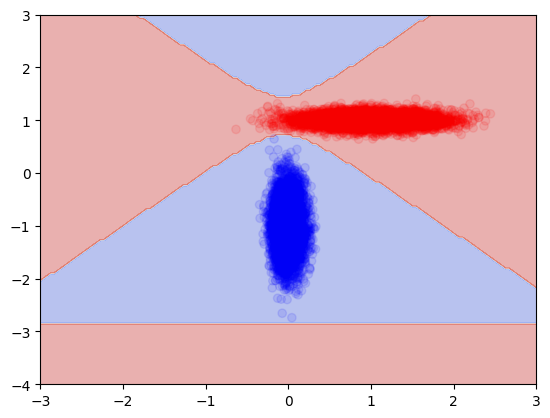

In [6]:
# Use the ht2d.models.HoeffdingTreeClassifier adapter instead of a raw river model
from collections import deque

n = 250  # window size
model = HoeffdingTreeClassifier()

seed = 42
rng = np.random.default_rng(seed)
g1 = GaussianMixture(
    mu=[[0, -1], [1, 1]],
    sigma=[[0.01, 0.2], [0.2, 0.01]],
    class_=[0, 1],
    p=[0.5, 0.5],
    n=80_000,
    rng=rng,
)

# Build training window
x_window = deque(maxlen=n)
y_window = deque(maxlen=n)

accumulate_examples(g1, n, x_window, y_window)
model.learn_many(np.array(x_window), np.array(y_window))

# 💡 FIX: Make classes_ sklearn-compatible *just for this cell*
model.classes_ = np.array(model.classes_, dtype=int)

# decision boundary
x0_min, x0_max = -3, 3
x1_min, x1_max = -4, 3
xx, yy = np.meshgrid(
    np.linspace(x0_min, x0_max, 400),
    np.linspace(x1_min, x1_max, 400),
)
X_grid = np.c_[xx.ravel(), yy.ravel()]

fig, ax = plt.subplots()
disp = DecisionBoundaryDisplay.from_estimator(
    model,
    X_grid,
    response_method="predict",
    cmap="coolwarm",
    alpha=0.4,
    grid_resolution=200,
    ax=ax,
)

# Plot actual points
x_1, x_2, c = [], [], []
for x, y in it.islice(g1.sample(), 10_000):
    x_1.append(x["x_0"])
    x_2.append(x["x_1"])
    c.append(y)

ax.scatter(x_1, x_2, c=c, cmap="bwr", alpha=0.1)
ax.set_xlim(x0_min, x0_max)
ax.set_ylim(x1_min, x1_max)
plt.show()


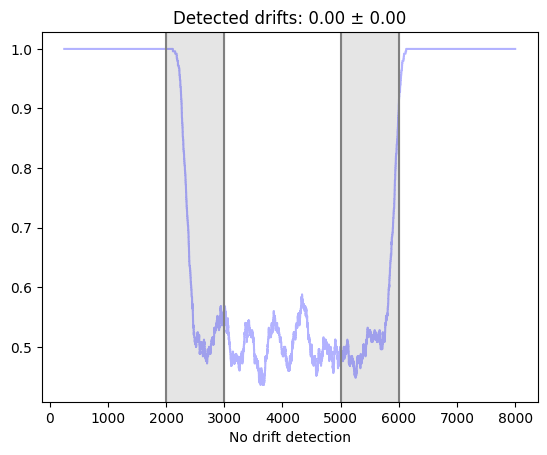

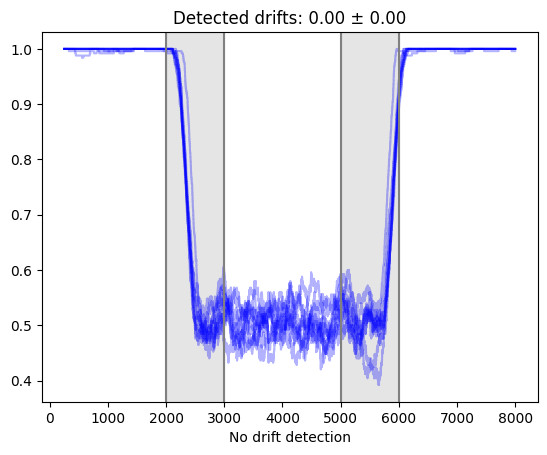

Baseline (NoDriftDetector) summary:
{'AA': 0.7734067346148885, 'ANR': 0.0, 'SNR': 0.0}


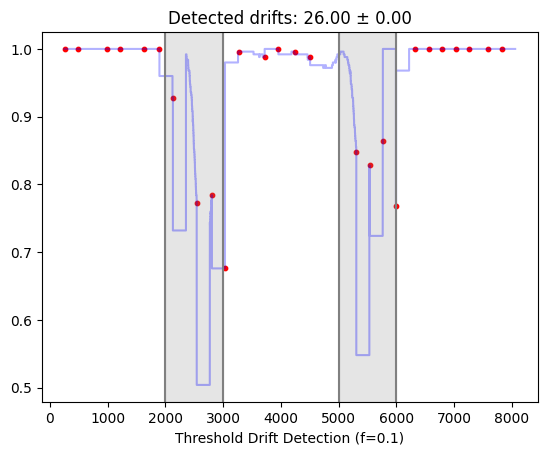

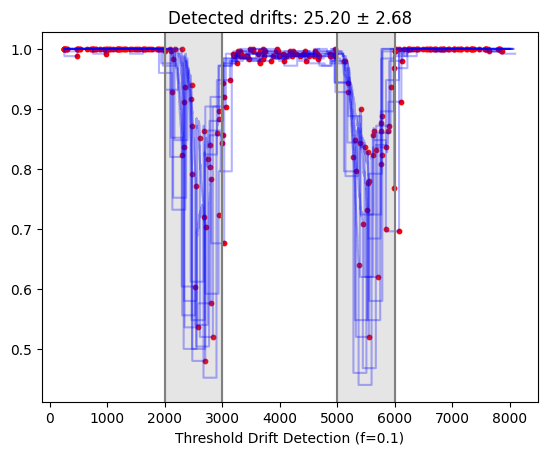

ThresholdDriftDetector summary:
{'AA': 0.9751555866378467, 'ANR': 25.2, 'SNR': 0.5609337343083474}


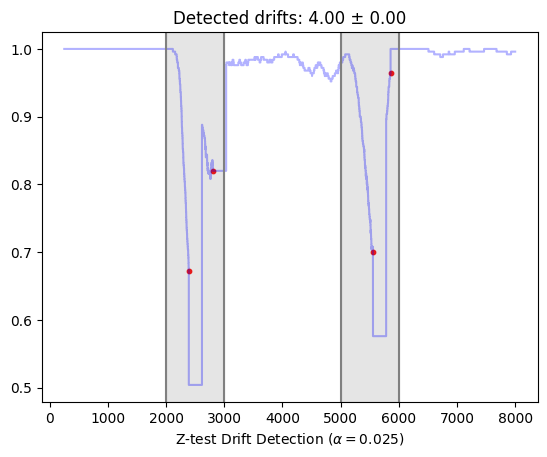

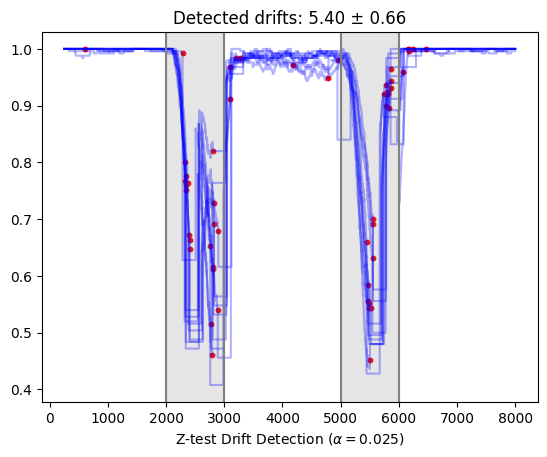

ZTestDriftDetector summary:
{'AA': 0.9674720723752699, 'ANR': 5.4, 'SNR': inf}


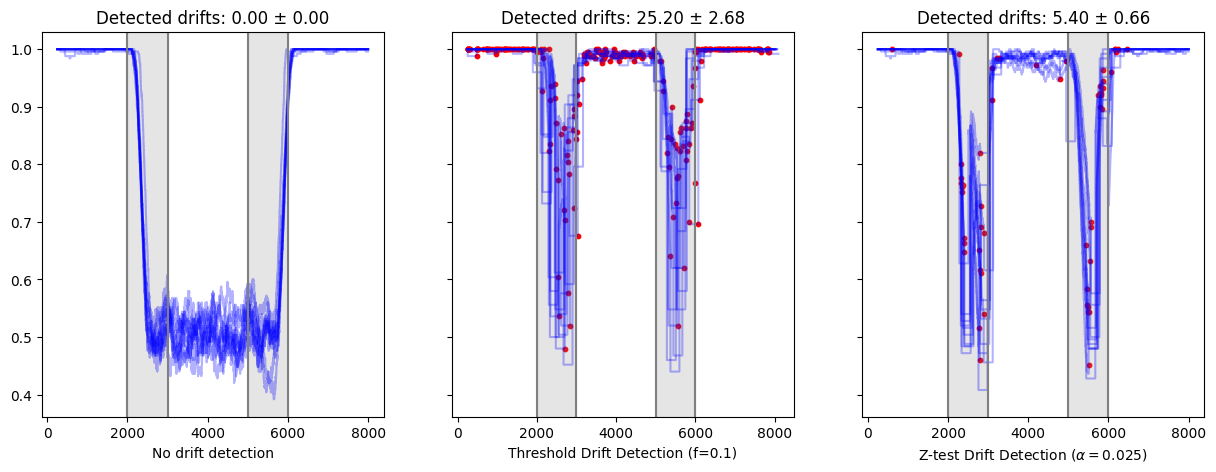

In [7]:
# Parameters
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter
max_t = 8_000

# --- No drift detector (baseline) ---
detector = NoDriftDetector()
seed = 42
stream = stream_factory_2_new(seed)
model = HoeffdingTreeClassifier()

accuracy, detected_drifts = experiment(n, nu, gamma, max_t, stream, detector, model)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy], [detected_drifts], stream, detector)
plt.show()

# Multiple seeds for baseline
seeds = np.arange(42, 142, 10)
baseline_accuracy_2 = []
baseline_detected_2 = []
for seed in seeds:
    stream = stream_factory_2_new(seed)
    model = HoeffdingTreeClassifier()
    detector = NoDriftDetector()
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    baseline_accuracy_2.append(acc)
    baseline_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, baseline_accuracy_2, baseline_detected_2, stream, detector)
plt.show()
# ---- Metrics summary (baseline) ----
# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_2_new(seeds[0]).drift_points

baseline_summary = summarize_runs(
    accuracies=baseline_accuracy_2,
    detected_drifts_list=baseline_detected_2,
    drift_points=drift_points,
    tol=n
)

print("Baseline (NoDriftDetector) summary:")
print(baseline_summary)

# --- Threshold detector ---
detector = ThresholdDriftDetector(f)
seed = 42
stream = stream_factory_2_new(seed)
model = HoeffdingTreeClassifier()

accuracy, detected_drifts = experiment(n, nu, gamma, max_t, stream, detector, model)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy], [detected_drifts], stream, detector)
plt.show()

seeds = np.arange(42, 142, 10)
thr_accuracy_2 = []
thr_detected_2 = []
for seed in seeds:
    stream = stream_factory_2_new(seed)
    model = HoeffdingTreeClassifier()
    detector = ThresholdDriftDetector(f)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    thr_accuracy_2.append(acc)
    thr_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, thr_accuracy_2, thr_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (threshold) ----
# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_2_new(seeds[0]).drift_points

thr_summary = summarize_runs(
    accuracies=thr_accuracy_2,
    detected_drifts_list=thr_detected_2,
    drift_points=drift_points,
    tol=n
)
print("ThresholdDriftDetector summary:")
print(thr_summary)

# --- Z-test detector ---
alpha = 0.025
detector = ZTestDriftDetector(alpha)
seed = 42
stream = stream_factory_2_new(seed)
model = HoeffdingTreeClassifier()

accuracy, detected_drifts = experiment(n, nu, gamma, max_t, stream, detector, model)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy], [detected_drifts], stream, detector)
plt.show()

seeds = np.arange(42, 142, 10)
z_accuracy_2 = []
z_detected_2 = []
for seed in seeds:
    stream = stream_factory_2_new(seed)
    model = HoeffdingTreeClassifier()
    detector = ZTestDriftDetector(alpha)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    z_accuracy_2.append(acc)
    z_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, z_accuracy_2, z_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (z-test) ----

# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_2_new(seeds[0]).drift_points

z_summary = summarize_runs(
    accuracies=z_accuracy_2,
    detected_drifts_list=z_detected_2,
    drift_points=drift_points,
    tol=n
)

print("ZTestDriftDetector summary:")
print(z_summary)

# --- Combined 3-panel figure for this scenario ---
fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(15, 5))
generate_figure(axes[0], baseline_accuracy_2, baseline_detected_2, stream, NoDriftDetector())
generate_figure(axes[1], thr_accuracy_2, thr_detected_2, stream, ThresholdDriftDetector(f))
generate_figure(axes[2], z_accuracy_2, z_detected_2, stream, ZTestDriftDetector(alpha))
plt.show()


Sudden Drift

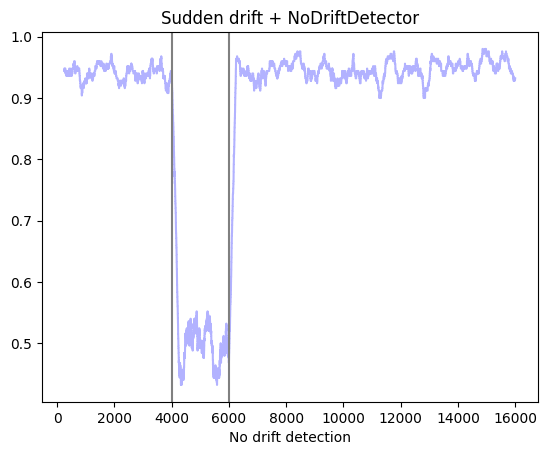

In [31]:
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter
max_t = 16_000

# 1) No drift detector (baseline) on sudden drift
detector = NoDriftDetector()
seed = 42
stream = stream_factory_sudden(seed)
# model = tree.HoeffdingTreeClassifier()
model = HoeffdingTreeClassifier()

accuracy_sudden_base, drifts_sudden_base = experiment(
    n, nu, gamma, max_t, stream, detector, model
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_sudden_base], [drifts_sudden_base], stream, detector)
ax.set_title("Sudden drift + NoDriftDetector")
plt.show()




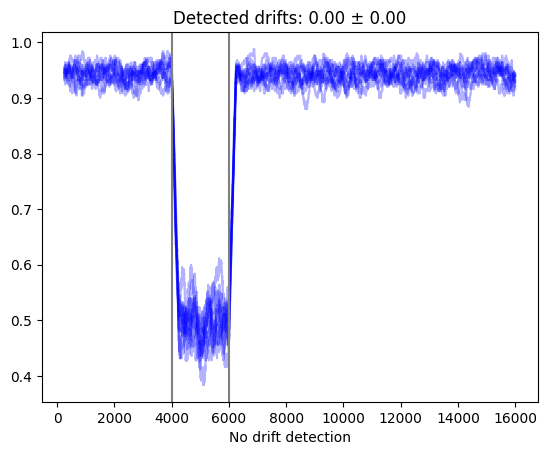

Baseline (NoDriftDetector) summary:
{'AA': 0.8856474128626755, 'ANR': 0.0, 'SNR': 0.0}


In [ ]:
# Multiple seeds for baseline
seeds = np.arange(42, 142, 10)
baseline_accuracy_2 = []
baseline_detected_2 = []
for seed in seeds:
    stream = stream_factory_sudden(seed)
    model = HoeffdingTreeClassifier()
    detector = NoDriftDetector()
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    baseline_accuracy_2.append(acc)
    baseline_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, baseline_accuracy_2, baseline_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (baseline) ----
# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_sudden(seeds[0]).drift_points

baseline_summary = summarize_runs(
    accuracies=baseline_accuracy_2,
    detected_drifts_list=baseline_detected_2,
    drift_points=drift_points,
    tol=n
)

print("Baseline (NoDriftDetector) summary:")
print(baseline_summary)

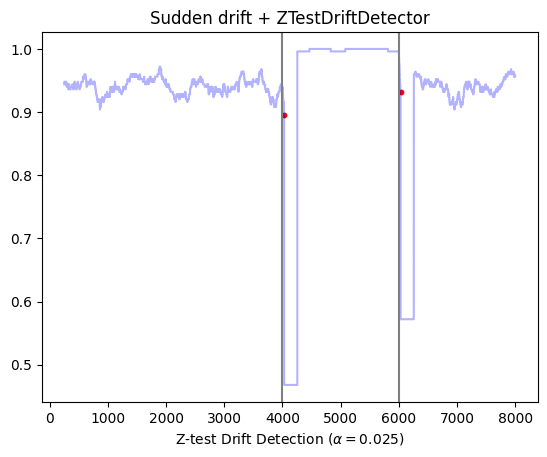

In [33]:
# 2) Z-test detector on sudden drift
n= 250     # window size
alpha = 0.025
detector = ZTestDriftDetector(alpha)
seed = 42
max_t = 8_000
stream = stream_factory_sudden(seed)
model = HoeffdingTreeClassifier()

accuracy_sudden_z, drifts_sudden_z = experiment(
    n, nu, gamma, max_t, stream, detector, model
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_sudden_z], [drifts_sudden_z], stream, detector)
ax.set_title("Sudden drift + ZTestDriftDetector")
plt.show()


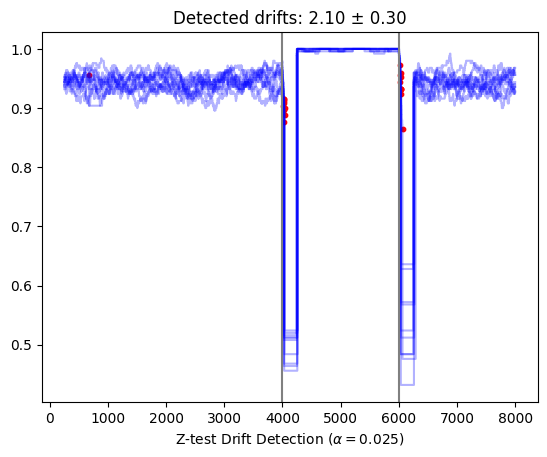

ZTestDriftDetector summary:
{'AA': 0.9565097337666929, 'ANR': 2.1, 'SNR': inf}


In [35]:
seeds = np.arange(42, 142, 10)
z_accuracy_2 = []
z_detected_2 = []
for seed in seeds:
    stream = stream_factory_sudden(seed)
    model = HoeffdingTreeClassifier()
    detector = ZTestDriftDetector(alpha)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    z_accuracy_2.append(acc)
    z_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, z_accuracy_2, z_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (z-test) ----

# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_sudden(seeds[0]).drift_points

z_summary = summarize_runs(
    accuracies=z_accuracy_2,
    detected_drifts_list=z_detected_2,
    drift_points=drift_points,
    tol=n
)

print("ZTestDriftDetector summary:")
print(z_summary)

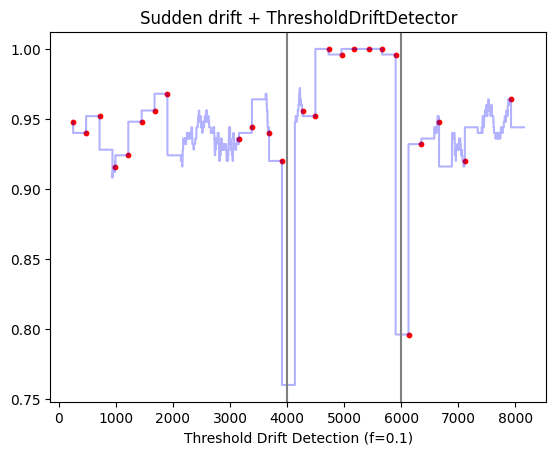

In [36]:
# 3) Threshold detector on sudden drift
max_t = 8_000

detector_thr = ThresholdDriftDetector(f)
seed = 42
stream = stream_factory_sudden(seed)
model = HoeffdingTreeClassifier()

accuracy_sudden_thr, drifts_sudden_thr = experiment(
    n, nu, gamma, max_t, stream, detector_thr, model
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_sudden_thr], [drifts_sudden_thr], stream, detector_thr)
ax.set_title("Sudden drift + ThresholdDriftDetector")
plt.show()

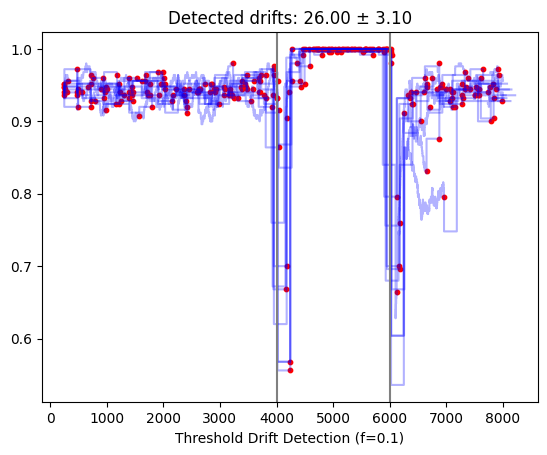

ThresholdDriftDetector summary:
{'AA': 0.9421327575269572, 'ANR': 26.0, 'SNR': 0.17342258131731816}


In [37]:
seeds = np.arange(42, 142, 10)
thr_accuracy_2 = []
thr_detected_2 = []
for seed in seeds:
    stream = stream_factory_sudden(seed)
    model = HoeffdingTreeClassifier()
    detector = ThresholdDriftDetector(f)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    thr_accuracy_2.append(acc)
    thr_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, thr_accuracy_2, thr_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (threshold) ----
# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_sudden(seeds[0]).drift_points

thr_summary = summarize_runs(
    accuracies=thr_accuracy_2,
    detected_drifts_list=thr_detected_2,
    drift_points=drift_points,
    tol=n
)
print("ThresholdDriftDetector summary:")
print(thr_summary)


River GaussianNB model - Gradual Drift

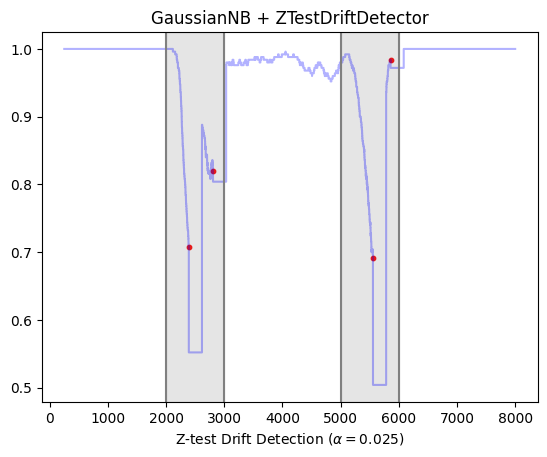

In [6]:

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

# Choose which stream scenario you want to test
seed = 42
stream = stream_factory_2_new(seed)   # or stream_factory(seed), stream_factory_3(seed), etc.

# Use river.naive_bayes.GaussianNB via our adapter
model = GaussianNBClassifier()

# Pick a detector – for example, Z-test
alpha = 0.025
detector = ZTestDriftDetector(alpha)

accuracy_gnb, detected_drifts_gnb = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream,
    detector=detector,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_gnb], [detected_drifts_gnb], stream, detector)
ax.set_title("GaussianNB + ZTestDriftDetector")
plt.show()


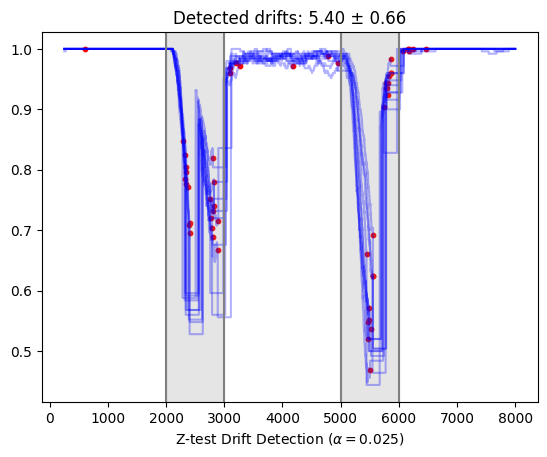

ZTestDriftDetector summary:
{'AA': 0.9718343857582354, 'ANR': 5.4, 'SNR': inf}


In [10]:
#ztest river gnb multiple seeds

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

alpha = 0.025

seeds = np.arange(42, 142, 10)
z_accuracy_2 = []
z_detected_2 = []
for seed in seeds:
    stream = stream_factory_2_new(seed)
    model = GaussianNBClassifier()
    detector = ZTestDriftDetector(alpha)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    z_accuracy_2.append(acc)
    z_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, z_accuracy_2, z_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (z-test) ----

# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_2_new(seeds[0]).drift_points

z_summary = summarize_runs(
    accuracies=z_accuracy_2,
    detected_drifts_list=z_detected_2,
    drift_points=drift_points,
    tol=n
)

print("ZTestDriftDetector summary:")
print(z_summary)

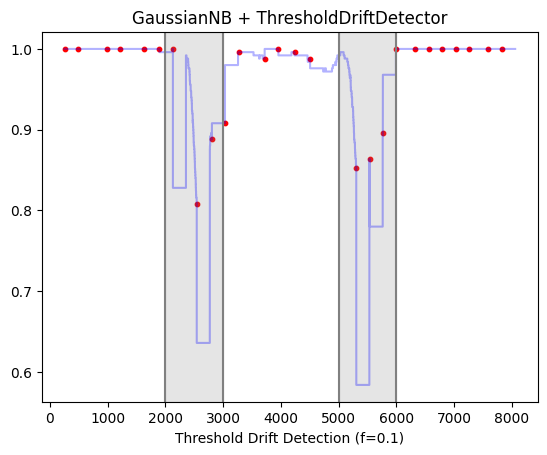

In [ ]:
# Threshold-based detector with River GaussianNB

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000
seed = 42


detector_thr = ThresholdDriftDetector(f)
stream2 = stream_factory_2_new(seed)   # new stream instance

model = GaussianNBClassifier()
accuracy_thr, drifts_thr = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream2,
    detector=detector_thr,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_thr], [drifts_thr], stream2, detector_thr)
ax.set_title("GaussianNB + ThresholdDriftDetector")
plt.show()


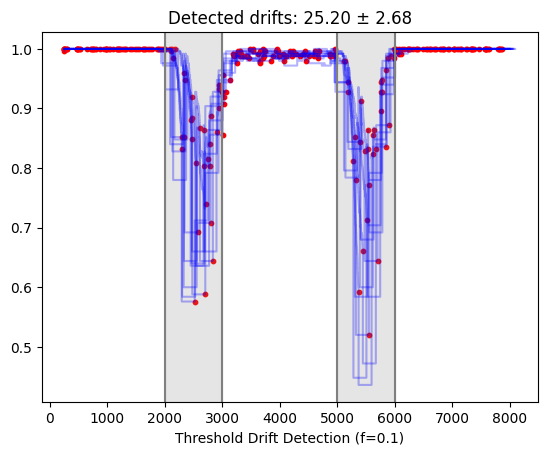

ThresholdDriftDetector summary:
{'AA': 0.976231915000653, 'ANR': 25.2, 'SNR': 0.5609337343083474}


In [9]:
#threshold river gnb multiple seeds

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

seeds = np.arange(42, 142, 10)
thr_accuracy_2 = []
thr_detected_2 = []
for seed in seeds:
    stream = stream_factory_2_new(seed)
    model = GaussianNBClassifier()
    detector = ThresholdDriftDetector(f)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    thr_accuracy_2.append(acc)
    thr_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, thr_accuracy_2, thr_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (threshold) ----
# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_2_new(seeds[0]).drift_points

thr_summary = summarize_runs(
    accuracies=thr_accuracy_2,
    detected_drifts_list=thr_detected_2,
    drift_points=drift_points,
    tol=n
)
print("ThresholdDriftDetector summary:")
print(thr_summary)


River GaussianNB model - Sudden Drift

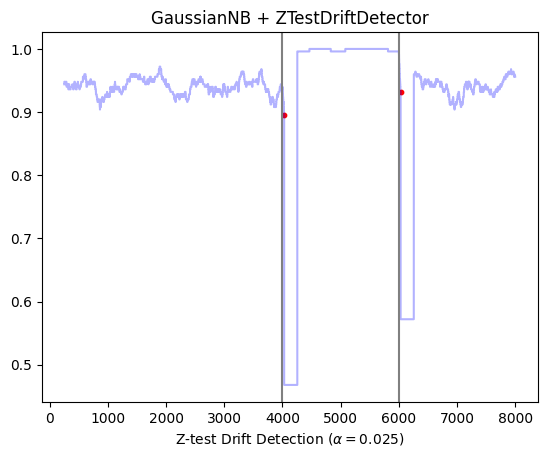

In [13]:
#Ztest Sudden 
# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

# Choose which stream scenario you want to test
seed = 42
stream = stream_factory_sudden(seed)   # or stream_factory(seed), stream_factory_3(seed), etc.

# Use river.naive_bayes.GaussianNB via our adapter
model = GaussianNBClassifier()

# Pick a detector – for example, Z-test
alpha = 0.025
detector = ZTestDriftDetector(alpha)

accuracy_gnb, detected_drifts_gnb = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream,
    detector=detector,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_gnb], [detected_drifts_gnb], stream, detector)
ax.set_title("GaussianNB + ZTestDriftDetector")
plt.show()


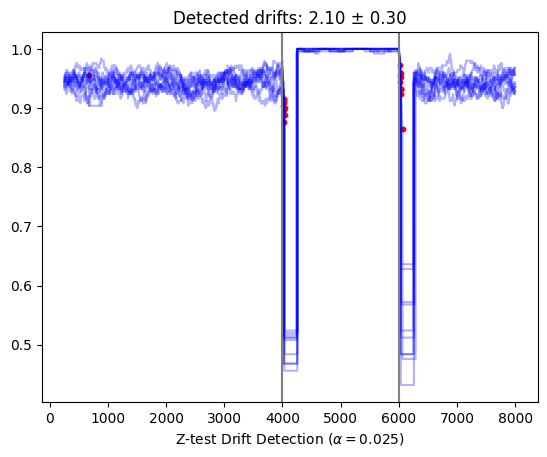

ZTestDriftDetector summary:
{'AA': 0.9565097885462054, 'ANR': 2.1, 'SNR': inf}


In [14]:
#ztest river gnb multiple seeds Sudden

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

alpha = 0.025

seeds = np.arange(42, 142, 10)
z_accuracy_2 = []
z_detected_2 = []
for seed in seeds:
    stream = stream_factory_sudden(seed)
    model = GaussianNBClassifier()
    detector = ZTestDriftDetector(alpha)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    z_accuracy_2.append(acc)
    z_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, z_accuracy_2, z_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (z-test) ----

# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_sudden(seeds[0]).drift_points

z_summary = summarize_runs(
    accuracies=z_accuracy_2,
    detected_drifts_list=z_detected_2,
    drift_points=drift_points,
    tol=n
)

print("ZTestDriftDetector summary:")
print(z_summary)

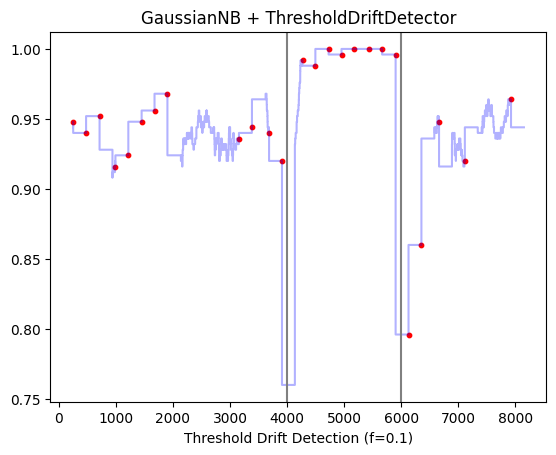

In [ ]:
# Threshold-based detector with River GaussianNB

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000
seed = 42


detector_thr = ThresholdDriftDetector(f)
stream2 = stream_factory_sudden(seed)   # new stream instance

model = GaussianNBClassifier()
accuracy_thr, drifts_thr = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream2,
    detector=detector_thr,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_thr], [drifts_thr], stream2, detector_thr)
ax.set_title("GaussianNB + ThresholdDriftDetector")
plt.show()

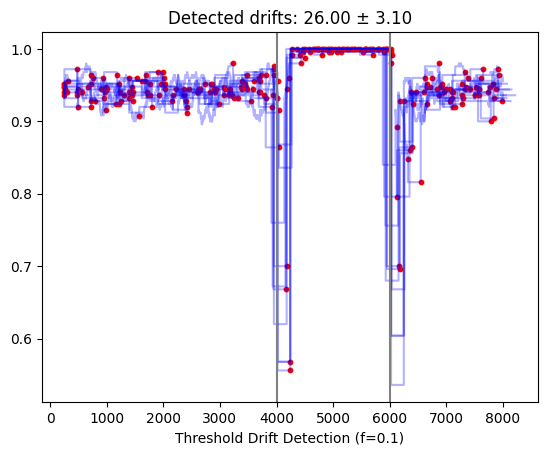

ThresholdDriftDetector summary:
{'AA': 0.9495463883127924, 'ANR': 26.0, 'SNR': 0.17342258131731816}


In [16]:
#threshold river gnb multiple seeds sudden drift

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

seeds = np.arange(42, 142, 10)
thr_accuracy_2 = []
thr_detected_2 = []
for seed in seeds:
    stream = stream_factory_sudden(seed)
    model = GaussianNBClassifier()
    detector = ThresholdDriftDetector(f)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    thr_accuracy_2.append(acc)
    thr_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, thr_accuracy_2, thr_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (threshold) ----
# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_sudden(seeds[0]).drift_points

thr_summary = summarize_runs(
    accuracies=thr_accuracy_2,
    detected_drifts_list=thr_detected_2,
    drift_points=drift_points,
    tol=n
)
print("ThresholdDriftDetector summary:")
print(thr_summary)

River PAClassifier - Gradual Drift

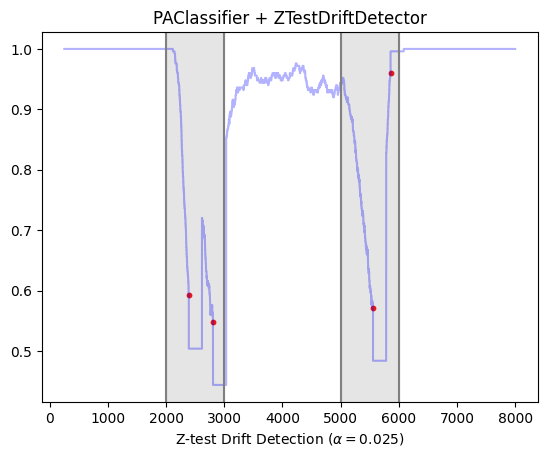

In [7]:
# PAClassifier experiment Gradual
# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

# Choose which stream scenario you want to test
seed = 42
stream = stream_factory_2_new(seed)   # or stream_factory(seed), stream_factory_3(seed), etc.

# Use river.naive_bayes.GaussianNB via our adapter
model = PAClassifier()

# Pick a detector – for example, Z-test
alpha = 0.025
detector = ZTestDriftDetector(alpha)

accuracy_pac, detected_drifts_pac = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream,
    detector=detector,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_pac], [detected_drifts_pac], stream, detector)
ax.set_title("PAClassifier + ZTestDriftDetector")
plt.show()

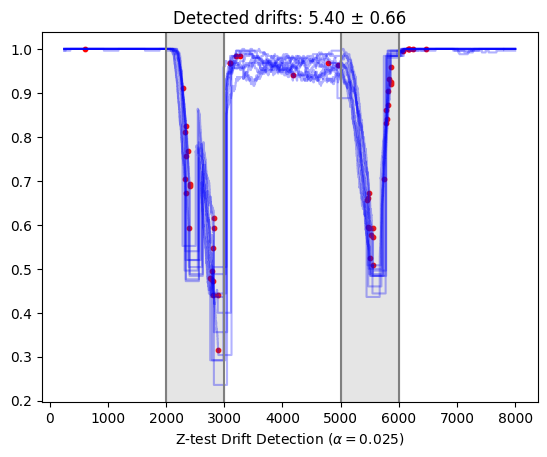

ZTestDriftDetector summary:
{'AA': 0.9563790128027809, 'ANR': 5.4, 'SNR': inf}


In [8]:
#ztest river pac multiple seeds

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

alpha = 0.025

seeds = np.arange(42, 142, 10)
z_accuracy_2 = []
z_detected_2 = []
for seed in seeds:
    stream = stream_factory_2_new(seed)
    model = PAClassifier()
    detector = ZTestDriftDetector(alpha)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    z_accuracy_2.append(acc)
    z_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, z_accuracy_2, z_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (z-test) ----

# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_2_new(seeds[0]).drift_points

z_summary = summarize_runs(
    accuracies=z_accuracy_2,
    detected_drifts_list=z_detected_2,
    drift_points=drift_points,
    tol=n
)

print("ZTestDriftDetector summary:")
print(z_summary)

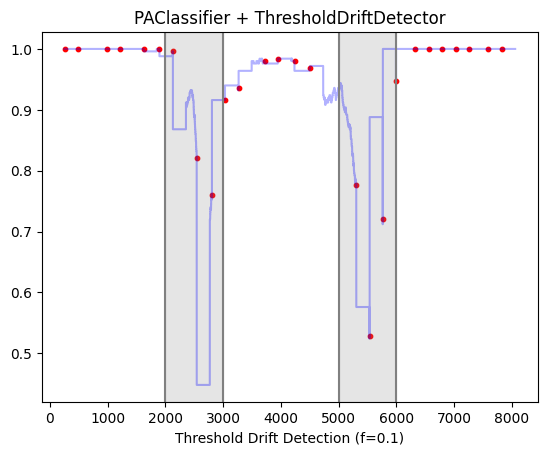

In [ ]:
# Threshold-based detector with River PAClassifier

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000
seed = 42


detector_thr = ThresholdDriftDetector(f)
stream2 = stream_factory_2_new(seed)   # new stream instance

model = PAClassifier()
accuracy_thr, drifts_thr = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream2,
    detector=detector_thr,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_thr], [drifts_thr], stream2, detector_thr)
ax.set_title("PAClassifier + ThresholdDriftDetector")
plt.show()


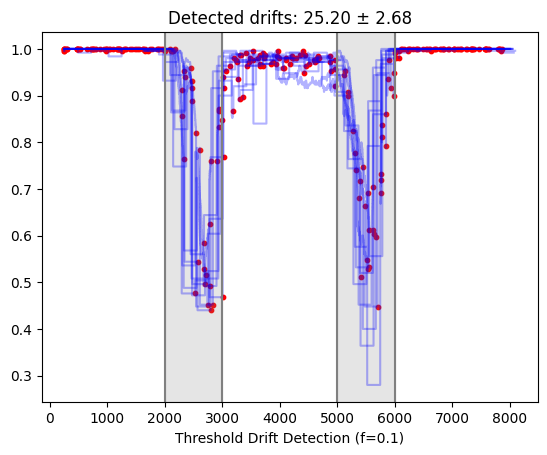

ThresholdDriftDetector summary:
{'AA': 0.9559786465347685, 'ANR': 25.2, 'SNR': 0.5609337343083474}


In [11]:
#threshold river Pac multiple seeds

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

seeds = np.arange(42, 142, 10)
thr_accuracy_2 = []
thr_detected_2 = []
for seed in seeds:
    stream = stream_factory_2_new(seed)
    model = PAClassifier()
    detector = ThresholdDriftDetector(f)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    thr_accuracy_2.append(acc)
    thr_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, thr_accuracy_2, thr_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (threshold) ----
# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_2_new(seeds[0]).drift_points

thr_summary = summarize_runs(
    accuracies=thr_accuracy_2,
    detected_drifts_list=thr_detected_2,
    drift_points=drift_points,
    tol=n
)
print("ThresholdDriftDetector summary:")
print(thr_summary)


River PAClassifier - Sudden Drift

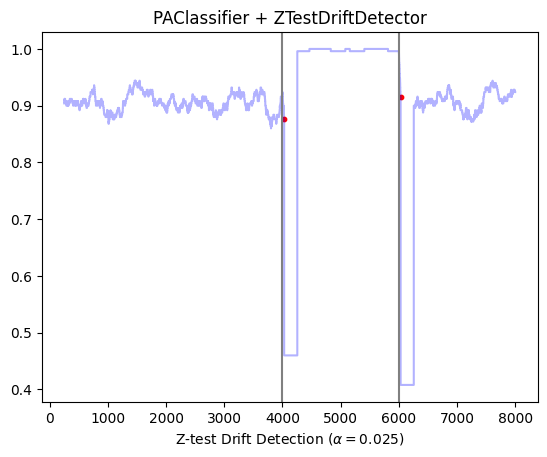

In [12]:
#Ztest Sudden 
# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

# Choose which stream scenario you want to test
seed = 42
stream = stream_factory_sudden(seed)   # or stream_factory(seed), stream_factory_3(seed), etc.

# Use river.naive_bayes.GaussianNB via our adapter
model = PAClassifier()

# Pick a detector – for example, Z-test
alpha = 0.025
detector = ZTestDriftDetector(alpha)

accuracy_gnb, detected_drifts_gnb = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream,
    detector=detector,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_gnb], [detected_drifts_gnb], stream, detector)
ax.set_title("PAClassifier + ZTestDriftDetector")
plt.show()

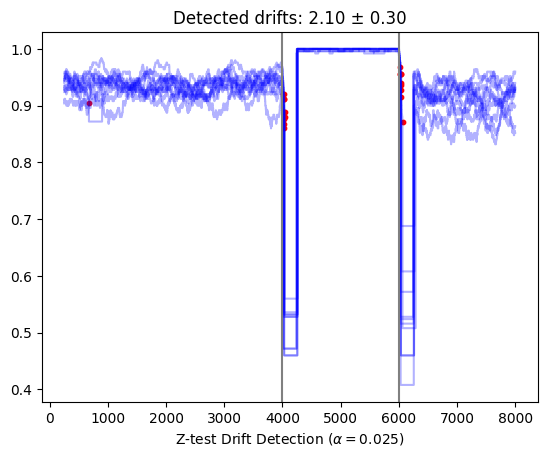

ZTestDriftDetector summary:
{'AA': 0.9444774332210691, 'ANR': 2.1, 'SNR': inf}


In [13]:
#ztest river pac multiple seeds Sudden

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

alpha = 0.025

seeds = np.arange(42, 142, 10)
z_accuracy_2 = []
z_detected_2 = []
for seed in seeds:
    stream = stream_factory_sudden(seed)
    model = PAClassifier()
    detector = ZTestDriftDetector(alpha)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    z_accuracy_2.append(acc)
    z_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, z_accuracy_2, z_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (z-test) ----

# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_sudden(seeds[0]).drift_points

z_summary = summarize_runs(
    accuracies=z_accuracy_2,
    detected_drifts_list=z_detected_2,
    drift_points=drift_points,
    tol=n
)

print("ZTestDriftDetector summary:")
print(z_summary)

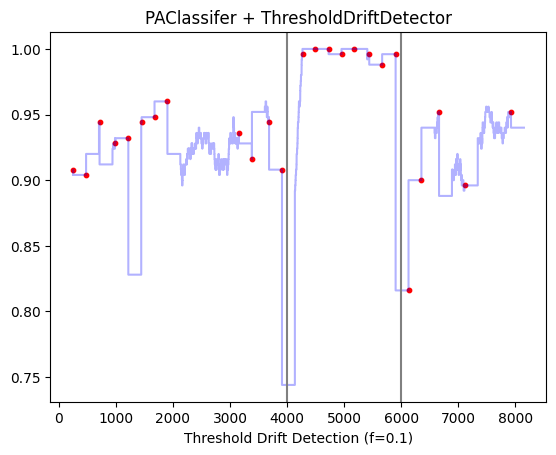

In [ ]:
# Threshold-based detector with River PAClassifier

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000
seed = 42


detector_thr = ThresholdDriftDetector(f)
stream2 = stream_factory_sudden(seed)   # new stream instance

model = PAClassifier()
accuracy_thr, drifts_thr = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream2,
    detector=detector_thr,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_thr], [drifts_thr], stream2, detector_thr)
ax.set_title("PAClassifer + ThresholdDriftDetector")
plt.show()

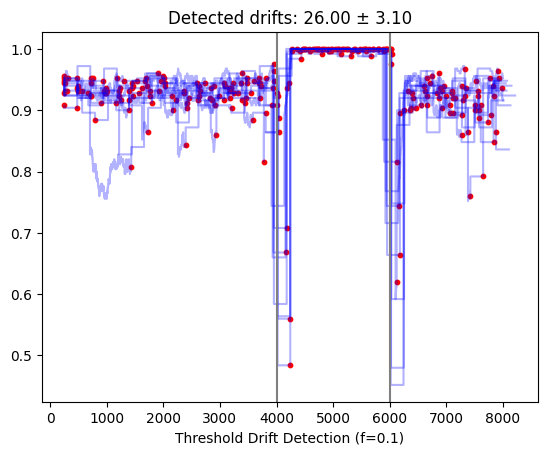

ThresholdDriftDetector summary:
{'AA': 0.9346039870282687, 'ANR': 26.0, 'SNR': 0.17342258131731816}


In [15]:
#threshold river pac multiple seeds sudden drift

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

seeds = np.arange(42, 142, 10)
thr_accuracy_2 = []
thr_detected_2 = []
for seed in seeds:
    stream = stream_factory_sudden(seed)
    model = PAClassifier()
    detector = ThresholdDriftDetector(f)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    thr_accuracy_2.append(acc)
    thr_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, thr_accuracy_2, thr_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (threshold) ----
# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_sudden(seeds[0]).drift_points

thr_summary = summarize_runs(
    accuracies=thr_accuracy_2,
    detected_drifts_list=thr_detected_2,
    drift_points=drift_points,
    tol=n
)
print("ThresholdDriftDetector summary:")
print(thr_summary)

SKlearn LinearSVC - Gradual Drift

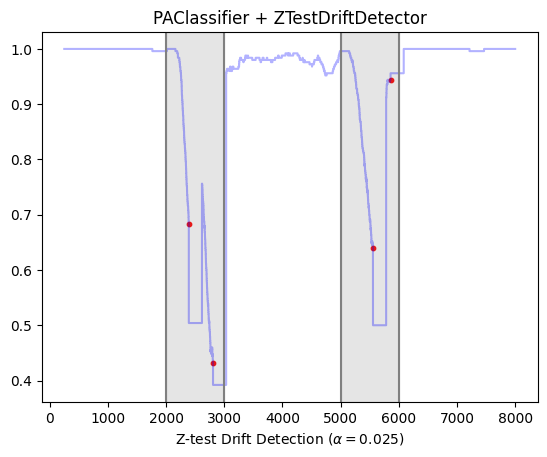

In [ ]:
# LinearSVC experiment Gradual
# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

# Choose which stream scenario you want to test
seed = 42
stream = stream_factory_2_new(seed)   # or stream_factory(seed), stream_factory_3(seed), etc.

# Use river.naive_bayes.GaussianNB via our adapter
model = SklearnLinearSVCClassifier()

# Pick a detector – for example, Z-test
alpha = 0.025
detector = ZTestDriftDetector(alpha)

accuracy_pac, detected_drifts_pac = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream,
    detector=detector,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_pac], [detected_drifts_pac], stream, detector)
ax.set_title("LinearSVC + ZTestDriftDetector")
plt.show()

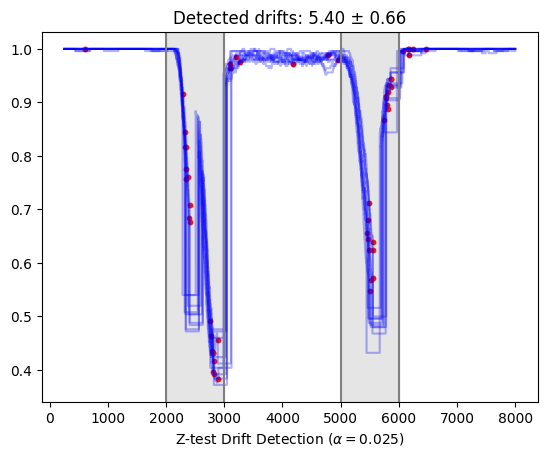

ZTestDriftDetector summary:
{'AA': 0.9665465494404348, 'ANR': 5.4, 'SNR': inf}


In [9]:
#ztest sklearn linearSVC multiple seeds

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

alpha = 0.025

seeds = np.arange(42, 142, 10)
z_accuracy_2 = []
z_detected_2 = []
for seed in seeds:
    stream = stream_factory_2_new(seed)
    model = SklearnLinearSVCClassifier()
    detector = ZTestDriftDetector(alpha)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    z_accuracy_2.append(acc)
    z_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, z_accuracy_2, z_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (z-test) ----

# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_2_new(seeds[0]).drift_points

z_summary = summarize_runs(
    accuracies=z_accuracy_2,
    detected_drifts_list=z_detected_2,
    drift_points=drift_points,
    tol=n
)

print("ZTestDriftDetector summary:")
print(z_summary)

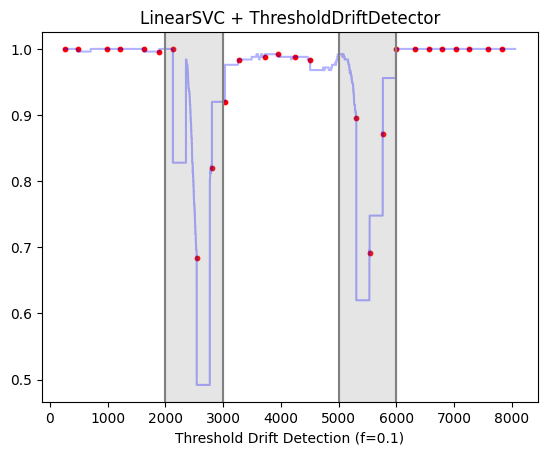

In [ ]:
# Threshold-based detector with Sklearn LenearSVC

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000
seed = 42


detector_thr = ThresholdDriftDetector(f)
stream2 = stream_factory_2_new(seed)   # new stream instance

model = SklearnLinearSVCClassifier()
accuracy_thr, drifts_thr = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream2,
    detector=detector_thr,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_thr], [drifts_thr], stream2, detector_thr)
ax.set_title("LinearSVC + ThresholdDriftDetector")
plt.show()


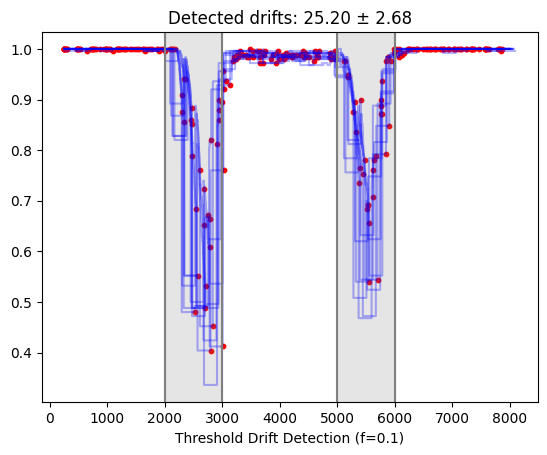

ThresholdDriftDetector summary:
{'AA': 0.971612523937238, 'ANR': 25.2, 'SNR': 0.5609337343083474}


In [11]:
#threshold sklearn linearSVC multiple seeds

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

seeds = np.arange(42, 142, 10)
thr_accuracy_2 = []
thr_detected_2 = []
for seed in seeds:
    stream = stream_factory_2_new(seed)
    model = SklearnLinearSVCClassifier()
    detector = ThresholdDriftDetector(f)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    thr_accuracy_2.append(acc)
    thr_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, thr_accuracy_2, thr_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (threshold) ----
# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_2_new(seeds[0]).drift_points

thr_summary = summarize_runs(
    accuracies=thr_accuracy_2,
    detected_drifts_list=thr_detected_2,
    drift_points=drift_points,
    tol=n
)
print("ThresholdDriftDetector summary:")
print(thr_summary)


SKlearn LinearSVC - Sudden Drift

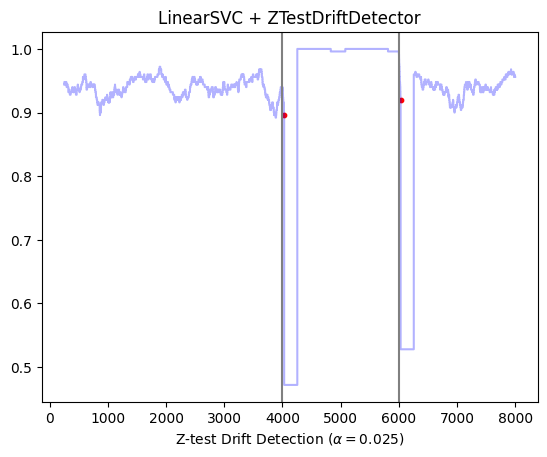

In [12]:
#Ztest Sudden 
# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

# Choose which stream scenario you want to test
seed = 42
stream = stream_factory_sudden(seed)   # or stream_factory(seed), stream_factory_3(seed), etc.

# Use river.naive_bayes.GaussianNB via our adapter
model = SklearnLinearSVCClassifier()

# Pick a detector – for example, Z-test
alpha = 0.025
detector = ZTestDriftDetector(alpha)

accuracy_gnb, detected_drifts_gnb = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream,
    detector=detector,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_gnb], [detected_drifts_gnb], stream, detector)
ax.set_title("LinearSVC + ZTestDriftDetector")
plt.show()

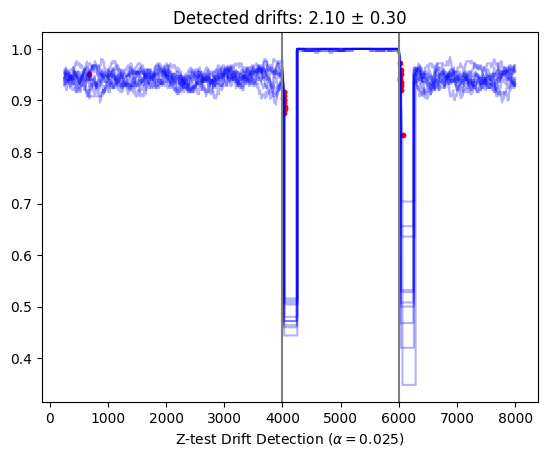

ZTestDriftDetector summary:
{'AA': 0.9563537825090804, 'ANR': 2.1, 'SNR': inf}


In [13]:
#ztest sklearn linearSVC multiple seeds Sudden

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

alpha = 0.025

seeds = np.arange(42, 142, 10)
z_accuracy_2 = []
z_detected_2 = []
for seed in seeds:
    stream = stream_factory_sudden(seed)
    model = SklearnLinearSVCClassifier()
    detector = ZTestDriftDetector(alpha)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    z_accuracy_2.append(acc)
    z_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, z_accuracy_2, z_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (z-test) ----

# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_sudden(seeds[0]).drift_points

z_summary = summarize_runs(
    accuracies=z_accuracy_2,
    detected_drifts_list=z_detected_2,
    drift_points=drift_points,
    tol=n
)

print("ZTestDriftDetector summary:")
print(z_summary)

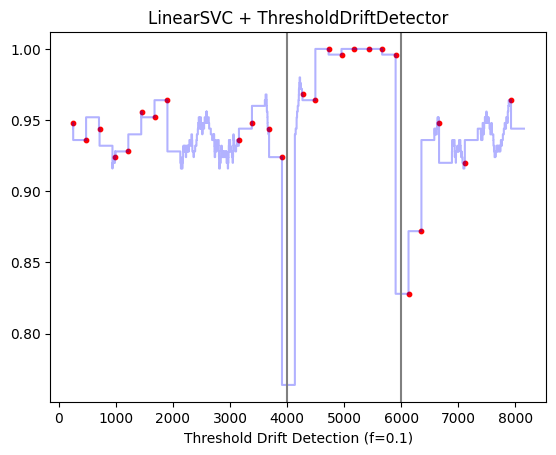

In [ ]:
# Threshold-based detector with Sklearn LinearSVC

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000
seed = 42


detector_thr = ThresholdDriftDetector(f)
stream2 = stream_factory_sudden(seed)   # new stream instance

model = SklearnLinearSVCClassifier()
accuracy_thr, drifts_thr = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream2,
    detector=detector_thr,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_thr], [drifts_thr], stream2, detector_thr)
ax.set_title("LinearSVC + ThresholdDriftDetector")
plt.show()

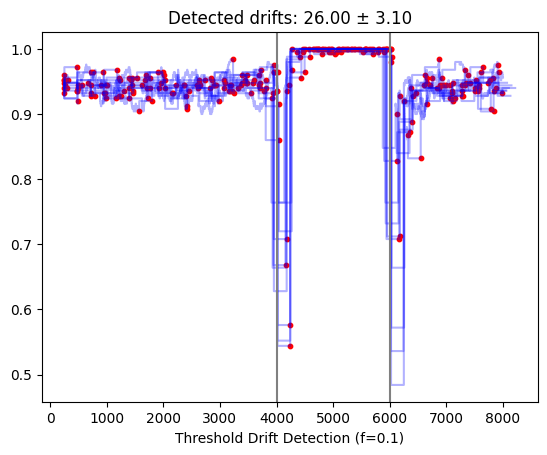

ThresholdDriftDetector summary:
{'AA': 0.9490545522517435, 'ANR': 26.0, 'SNR': 0.17342258131731816}


In [15]:
#threshold sklearn linearSVC multiple seeds sudden drift

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

seeds = np.arange(42, 142, 10)
thr_accuracy_2 = []
thr_detected_2 = []
for seed in seeds:
    stream = stream_factory_sudden(seed)
    model = SklearnLinearSVCClassifier()
    detector = ThresholdDriftDetector(f)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    thr_accuracy_2.append(acc)
    thr_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, thr_accuracy_2, thr_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (threshold) ----
# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_sudden(seeds[0]).drift_points

thr_summary = summarize_runs(
    accuracies=thr_accuracy_2,
    detected_drifts_list=thr_detected_2,
    drift_points=drift_points,
    tol=n
)
print("ThresholdDriftDetector summary:")
print(thr_summary)

SKlearn RBFSVCClassifier - Gradual Drift

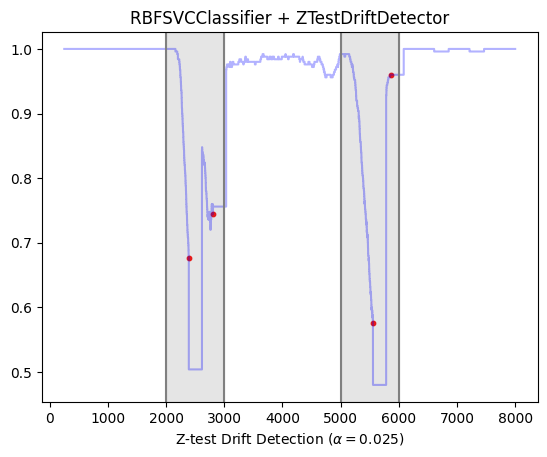

In [7]:
# RBFSVCClassifier experiment Gradual
# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

# Choose which stream scenario you want to test
seed = 42
stream = stream_factory_2_new(seed)   # or stream_factory(seed), stream_factory_3(seed), etc.

# Use river.naive_bayes.GaussianNB via our adapter
model =SklearnRBFSVCClassifier()

# Pick a detector – for example, Z-test
alpha = 0.025
detector = ZTestDriftDetector(alpha)

accuracy_pac, detected_drifts_pac = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream,
    detector=detector,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_pac], [detected_drifts_pac], stream, detector)
ax.set_title("RBFSVCClassifier + ZTestDriftDetector")
plt.show()

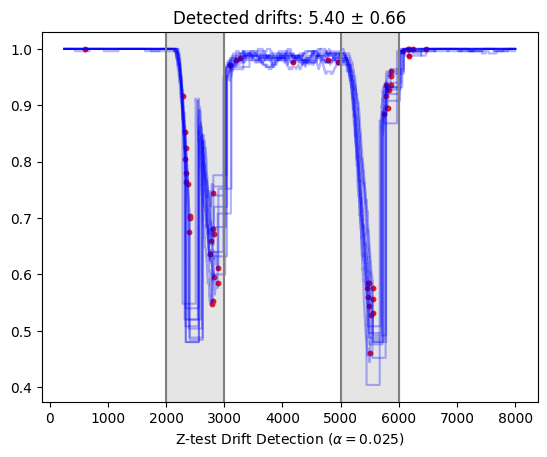

ZTestDriftDetector summary:
{'AA': 0.9691187605770167, 'ANR': 5.4, 'SNR': inf}


In [8]:
#ztest sklearn RBFSVCClassifier multiple seeds

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

alpha = 0.025

seeds = np.arange(42, 142, 10)
z_accuracy_2 = []
z_detected_2 = []
for seed in seeds:
    stream = stream_factory_2_new(seed)
    model = SklearnRBFSVCClassifier()
    detector = ZTestDriftDetector(alpha)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    z_accuracy_2.append(acc)
    z_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, z_accuracy_2, z_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (z-test) ----

# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_2_new(seeds[0]).drift_points

z_summary = summarize_runs(
    accuracies=z_accuracy_2,
    detected_drifts_list=z_detected_2,
    drift_points=drift_points,
    tol=n
)

print("ZTestDriftDetector summary:")
print(z_summary)

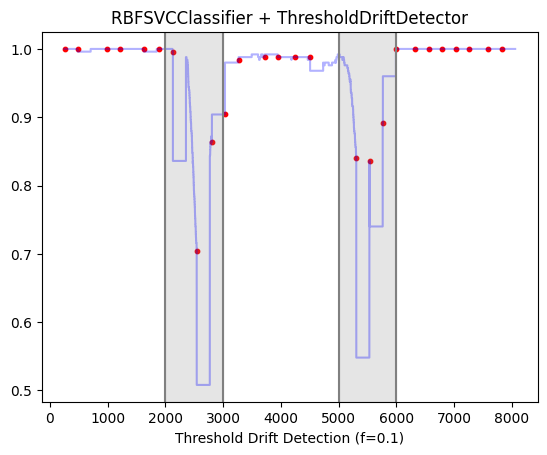

In [ ]:
# Threshold-based detector with Sklearn RBFSVCClassifier

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000
seed = 42


detector_thr = ThresholdDriftDetector(f)
stream2 = stream_factory_2_new(seed)   # new stream instance

model = SklearnRBFSVCClassifier()
accuracy_thr, drifts_thr = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream2,
    detector=detector_thr,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_thr], [drifts_thr], stream2, detector_thr)
ax.set_title("RBFSVCClassifier + ThresholdDriftDetector")
plt.show()


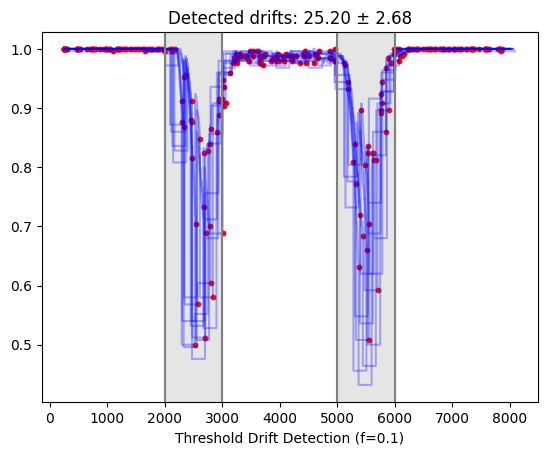

ThresholdDriftDetector summary:
{'AA': 0.9734430699568193, 'ANR': 25.2, 'SNR': 0.5609337343083474}


In [10]:
#threshold sklearn RBFSVCClassifier multiple seeds

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

seeds = np.arange(42, 142, 10)
thr_accuracy_2 = []
thr_detected_2 = []
for seed in seeds:
    stream = stream_factory_2_new(seed)
    model = SklearnRBFSVCClassifier()
    detector = ThresholdDriftDetector(f)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    thr_accuracy_2.append(acc)
    thr_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, thr_accuracy_2, thr_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (threshold) ----
# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_2_new(seeds[0]).drift_points

thr_summary = summarize_runs(
    accuracies=thr_accuracy_2,
    detected_drifts_list=thr_detected_2,
    drift_points=drift_points,
    tol=n
)
print("ThresholdDriftDetector summary:")
print(thr_summary)


SKlearn RBFSVCClassifier - Sudden Drift

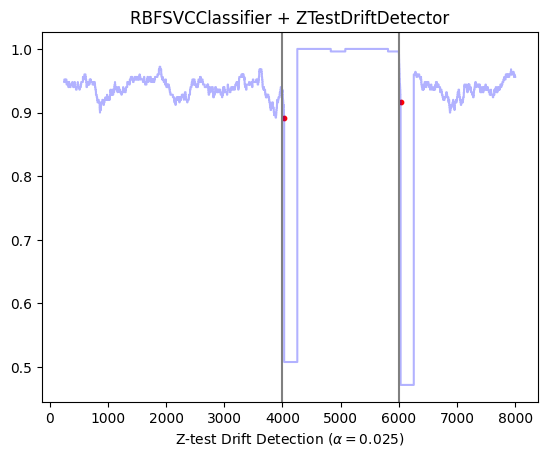

In [11]:
#Ztest Sudden 
# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

# Choose which stream scenario you want to test
seed = 42
stream = stream_factory_sudden(seed)   # or stream_factory(seed), stream_factory_3(seed), etc.

# Use via our adapter
model = SklearnRBFSVCClassifier()

# Pick a detector – for example, Z-test
alpha = 0.025
detector = ZTestDriftDetector(alpha)

accuracy_gnb, detected_drifts_gnb = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream,
    detector=detector,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_gnb], [detected_drifts_gnb], stream, detector)
ax.set_title("RBFSVCClassifier + ZTestDriftDetector")
plt.show()

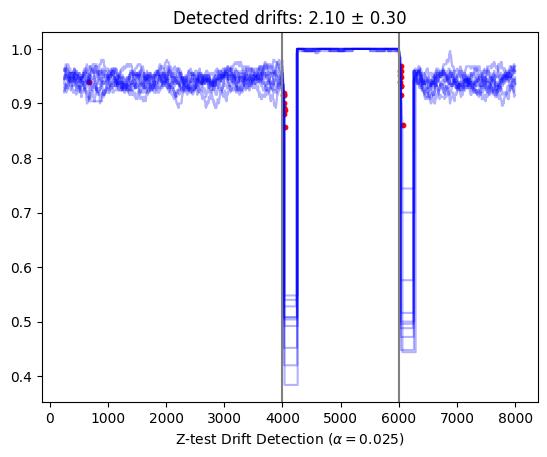

ZTestDriftDetector summary:
{'AA': 0.955632014015567, 'ANR': 2.1, 'SNR': inf}


In [12]:
#ztest sklearn RBFSVCClassifier multiple seeds Sudden

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

alpha = 0.025

seeds = np.arange(42, 142, 10)
z_accuracy_2 = []
z_detected_2 = []
for seed in seeds:
    stream = stream_factory_sudden(seed)
    model = SklearnRBFSVCClassifier()
    detector = ZTestDriftDetector(alpha)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    z_accuracy_2.append(acc)
    z_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, z_accuracy_2, z_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (z-test) ----

# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_sudden(seeds[0]).drift_points

z_summary = summarize_runs(
    accuracies=z_accuracy_2,
    detected_drifts_list=z_detected_2,
    drift_points=drift_points,
    tol=n
)

print("ZTestDriftDetector summary:")
print(z_summary)

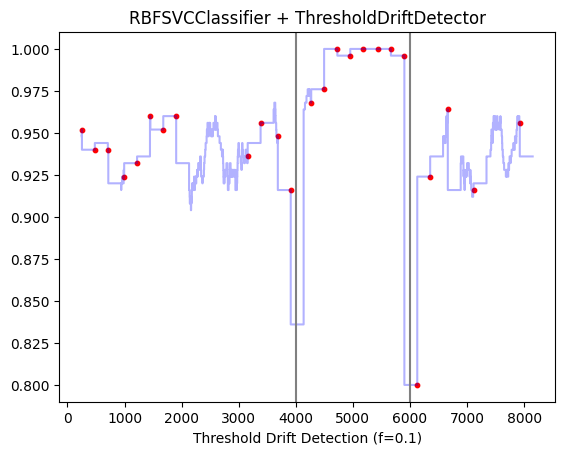

In [ ]:
# Threshold-based detector with Sklearn RBFSVCClassifier

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000
seed = 42


detector_thr = ThresholdDriftDetector(f)
stream2 = stream_factory_sudden(seed)   # new stream instance

model = SklearnRBFSVCClassifier()
accuracy_thr, drifts_thr = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream2,
    detector=detector_thr,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_thr], [drifts_thr], stream2, detector_thr)
ax.set_title("RBFSVCClassifier + ThresholdDriftDetector")
plt.show()

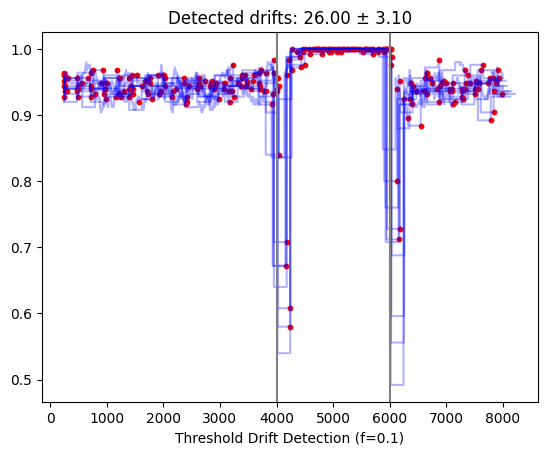

ThresholdDriftDetector summary:
{'AA': 0.9507728928354731, 'ANR': 26.0, 'SNR': 0.17342258131731816}


In [14]:
#threshold sklearn RBFSVCClassifier multiple seeds sudden drift

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

seeds = np.arange(42, 142, 10)
thr_accuracy_2 = []
thr_detected_2 = []
for seed in seeds:
    stream = stream_factory_sudden(seed)
    model = SklearnRBFSVCClassifier()
    detector = ThresholdDriftDetector(f)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    thr_accuracy_2.append(acc)
    thr_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, thr_accuracy_2, thr_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (threshold) ----
# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_sudden(seeds[0]).drift_points

thr_summary = summarize_runs(
    accuracies=thr_accuracy_2,
    detected_drifts_list=thr_detected_2,
    drift_points=drift_points,
    tol=n
)
print("ThresholdDriftDetector summary:")
print(thr_summary)

River Adaptive RandomForest - Gradual Drift

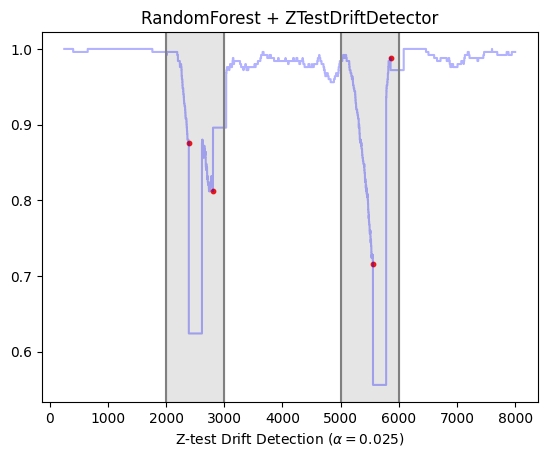

In [5]:
# RandomForest experiment Gradual
# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

# Choose which stream scenario you want to test
seed = 42
stream = stream_factory_2_new(seed)   # or stream_factory(seed), stream_factory_3(seed), etc.

# Use river.naive_bayes.GaussianNB via our adapter
model =AdaptiveRandomForestClassifier(n_models=10)

# Pick a detector – for example, Z-test
alpha = 0.025
detector = ZTestDriftDetector(alpha)

accuracy_pac, detected_drifts_pac = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream,
    detector=detector,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_pac], [detected_drifts_pac], stream, detector)
ax.set_title("RandomForest + ZTestDriftDetector")
plt.show()

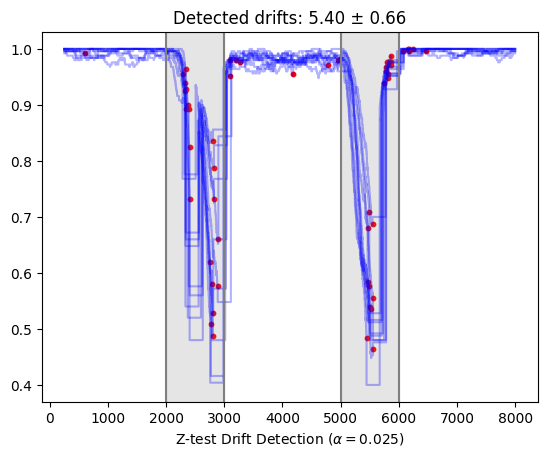

ZTestDriftDetector summary:
{'AA': 0.9683325595637484, 'ANR': 5.4, 'SNR': inf}


In [6]:
#ztest River ARFClassifier multiple seeds

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

alpha = 0.025

seeds = np.arange(42, 142, 10)
z_accuracy_2 = []
z_detected_2 = []
for seed in seeds:
    stream = stream_factory_2_new(seed)
    model = AdaptiveRandomForestClassifier()
    detector = ZTestDriftDetector(alpha)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    z_accuracy_2.append(acc)
    z_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, z_accuracy_2, z_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (z-test) ----

# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_2_new(seeds[0]).drift_points

z_summary = summarize_runs(
    accuracies=z_accuracy_2,
    detected_drifts_list=z_detected_2,
    drift_points=drift_points,
    tol=n
)

print("ZTestDriftDetector summary:")
print(z_summary)

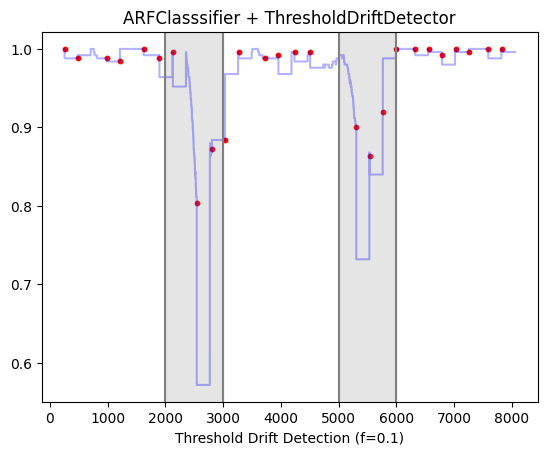

In [ ]:
# Threshold-based detector with River ARFClassifier

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000
seed = 42


detector_thr = ThresholdDriftDetector(f)
stream2 = stream_factory_2_new(seed)   # new stream instance

model = AdaptiveRandomForestClassifier()
accuracy_thr, drifts_thr = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream2,
    detector=detector_thr,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_thr], [drifts_thr], stream2, detector_thr)
ax.set_title("ARFClasssifier + ThresholdDriftDetector")
plt.show()


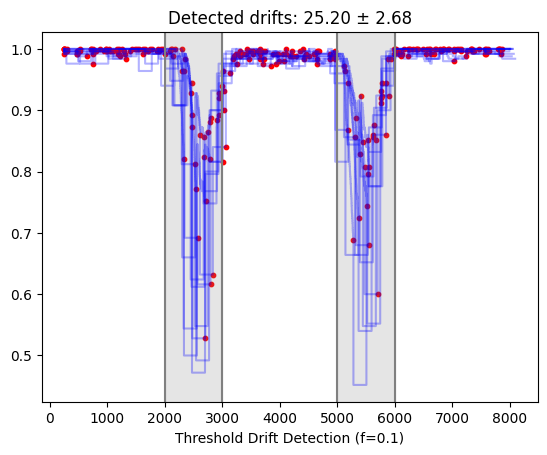

ThresholdDriftDetector summary:
{'AA': 0.9772847913460708, 'ANR': 25.2, 'SNR': 0.5609337343083474}


In [8]:
#threshold river ARFClassifier multiple seeds

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

seeds = np.arange(42, 142, 10)
thr_accuracy_2 = []
thr_detected_2 = []
for seed in seeds:
    stream = stream_factory_2_new(seed)
    model = AdaptiveRandomForestClassifier()
    detector = ThresholdDriftDetector(f)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    thr_accuracy_2.append(acc)
    thr_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, thr_accuracy_2, thr_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (threshold) ----
# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_2_new(seeds[0]).drift_points

thr_summary = summarize_runs(
    accuracies=thr_accuracy_2,
    detected_drifts_list=thr_detected_2,
    drift_points=drift_points,
    tol=n
)
print("ThresholdDriftDetector summary:")
print(thr_summary)


River Adaptive RandomForest - Sudden Drift

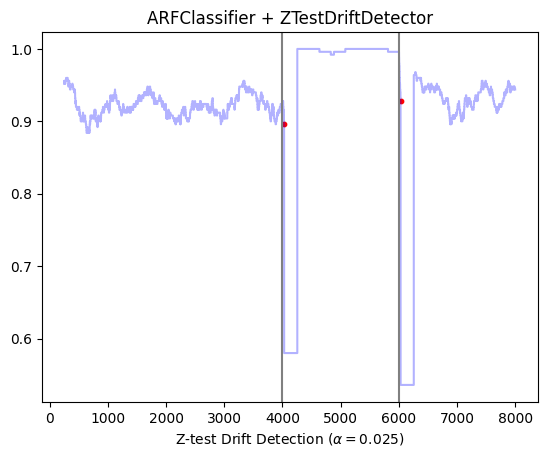

In [9]:
#Ztest Sudden 
# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

# Choose which stream scenario you want to test
seed = 42
stream = stream_factory_sudden(seed)   # or stream_factory(seed), stream_factory_3(seed), etc.

# Use via our adapter
model = AdaptiveRandomForestClassifier()

# Pick a detector – for example, Z-test
alpha = 0.025
detector = ZTestDriftDetector(alpha)

accuracy_gnb, detected_drifts_gnb = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream,
    detector=detector,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_gnb], [detected_drifts_gnb], stream, detector)
ax.set_title("ARFClassifier + ZTestDriftDetector")
plt.show()

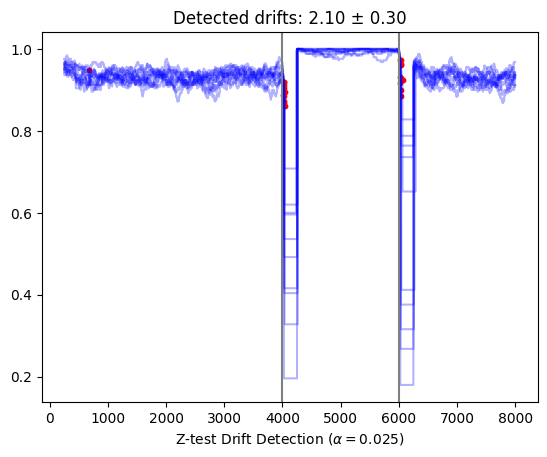

ZTestDriftDetector summary:
{'AA': 0.9471280281964711, 'ANR': 2.1, 'SNR': inf}


In [10]:
#ztest river ARFClassifier multiple seeds Sudden

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

alpha = 0.025

seeds = np.arange(42, 142, 10)
z_accuracy_2 = []
z_detected_2 = []
for seed in seeds:
    stream = stream_factory_sudden(seed)
    model = AdaptiveRandomForestClassifier()
    detector = ZTestDriftDetector(alpha)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    z_accuracy_2.append(acc)
    z_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, z_accuracy_2, z_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (z-test) ----

# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_sudden(seeds[0]).drift_points

z_summary = summarize_runs(
    accuracies=z_accuracy_2,
    detected_drifts_list=z_detected_2,
    drift_points=drift_points,
    tol=n
)

print("ZTestDriftDetector summary:")
print(z_summary)

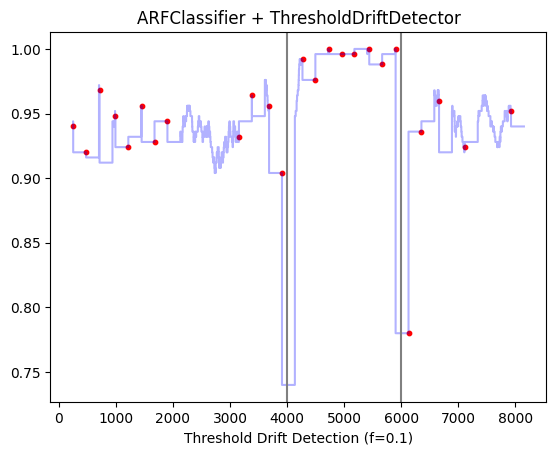

In [ ]:
# Threshold-based detector with River ARFClassifier

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000
seed = 42


detector_thr = ThresholdDriftDetector(f)
stream2 = stream_factory_sudden(seed)   # new stream instance

model = AdaptiveRandomForestClassifier()
accuracy_thr, drifts_thr = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream2,
    detector=detector_thr,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_thr], [drifts_thr], stream2, detector_thr)
ax.set_title("ARFClassifier + ThresholdDriftDetector")
plt.show()

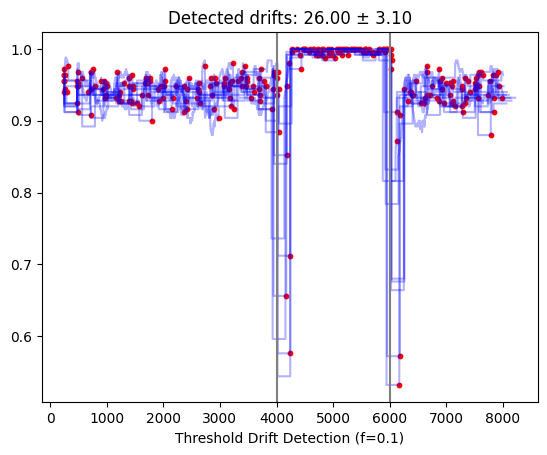

ThresholdDriftDetector summary:
{'AA': 0.9510797022034765, 'ANR': 26.0, 'SNR': 0.17342258131731816}


In [12]:
#threshold river ARFClassifier multiple seeds sudden drift

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

seeds = np.arange(42, 142, 10)
thr_accuracy_2 = []
thr_detected_2 = []
for seed in seeds:
    stream = stream_factory_sudden(seed)
    model = AdaptiveRandomForestClassifier()
    detector = ThresholdDriftDetector(f)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    thr_accuracy_2.append(acc)
    thr_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, thr_accuracy_2, thr_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (threshold) ----
# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_sudden(seeds[0]).drift_points

thr_summary = summarize_runs(
    accuracies=thr_accuracy_2,
    detected_drifts_list=thr_detected_2,
    drift_points=drift_points,
    tol=n
)
print("ThresholdDriftDetector summary:")
print(thr_summary)

River LogisticRegression - Gradual Drift

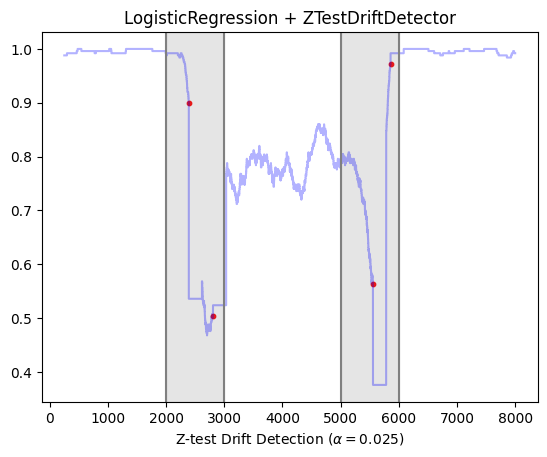

In [5]:
# LogisticRegression experiment Gradual
# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

# Choose which stream scenario you want to test
seed = 42
stream = stream_factory_2_new(seed)   # or stream_factory(seed), stream_factory_3(seed), etc.

# Use river.naive_bayes.GaussianNB via our adapter
model =LogisticRegressionClassifier()

# Pick a detector – for example, Z-test
alpha = 0.025
detector = ZTestDriftDetector(alpha)

accuracy_pac, detected_drifts_pac = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream,
    detector=detector,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_pac], [detected_drifts_pac], stream, detector)
ax.set_title("LogisticRegression + ZTestDriftDetector")
plt.show()

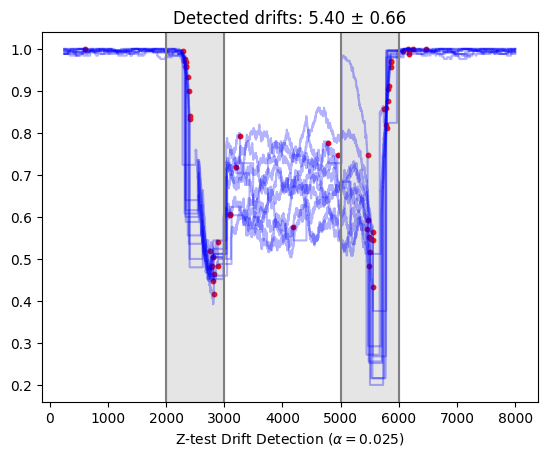

ZTestDriftDetector summary:
{'AA': 0.859387083093913, 'ANR': 5.4, 'SNR': inf}


In [6]:
#ztest River LogisticRegression multiple seeds

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

alpha = 0.025

seeds = np.arange(42, 142, 10)
z_accuracy_2 = []
z_detected_2 = []
for seed in seeds:
    stream = stream_factory_2_new(seed)
    model = LogisticRegressionClassifier()
    detector = ZTestDriftDetector(alpha)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    z_accuracy_2.append(acc)
    z_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, z_accuracy_2, z_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (z-test) ----

# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_2_new(seeds[0]).drift_points

z_summary = summarize_runs(
    accuracies=z_accuracy_2,
    detected_drifts_list=z_detected_2,
    drift_points=drift_points,
    tol=n
)

print("ZTestDriftDetector summary:")
print(z_summary)

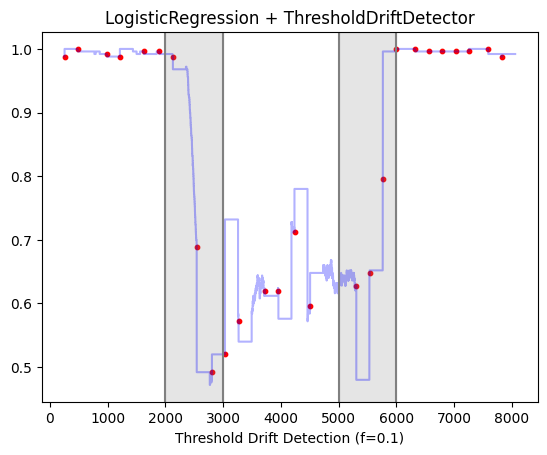

In [7]:
# Threshold-based detector with River LogisticRegression

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000
seed = 42


detector_thr = ThresholdDriftDetector(f)
stream2 = stream_factory_2_new(seed)   # new stream instance

model = LogisticRegressionClassifier()
accuracy_thr, drifts_thr = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream2,
    detector=detector_thr,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_thr], [drifts_thr], stream2, detector_thr)
ax.set_title("LogisticRegression + ThresholdDriftDetector")
plt.show()


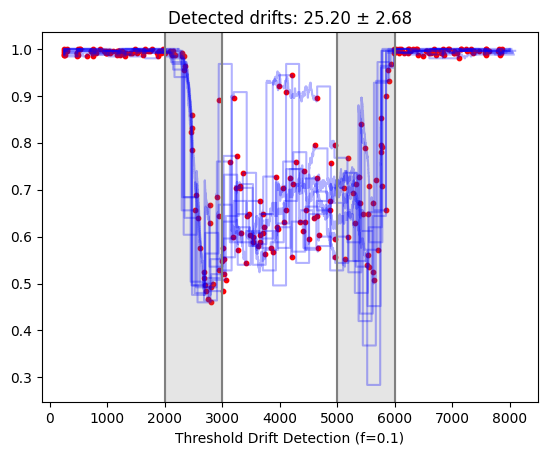

ThresholdDriftDetector summary:
{'AA': 0.8665458762449353, 'ANR': 25.2, 'SNR': 0.5609337343083474}


In [8]:
#threshold river LogisticRegression multiple seeds

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

seeds = np.arange(42, 142, 10)
thr_accuracy_2 = []
thr_detected_2 = []
for seed in seeds:
    stream = stream_factory_2_new(seed)
    model = LogisticRegressionClassifier()
    detector = ThresholdDriftDetector(f)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    thr_accuracy_2.append(acc)
    thr_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, thr_accuracy_2, thr_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (threshold) ----
# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_2_new(seeds[0]).drift_points

thr_summary = summarize_runs(
    accuracies=thr_accuracy_2,
    detected_drifts_list=thr_detected_2,
    drift_points=drift_points,
    tol=n
)
print("ThresholdDriftDetector summary:")
print(thr_summary)


River LogisticRegression - Sudden Drift

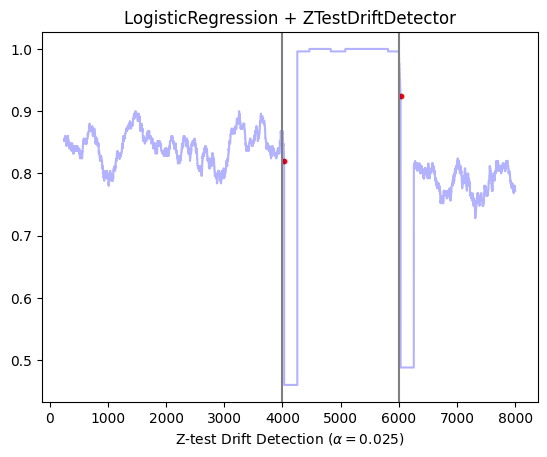

In [9]:
#Ztest Sudden 
# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

# Choose which stream scenario you want to test
seed = 42
stream = stream_factory_sudden(seed)   # or stream_factory(seed), stream_factory_3(seed), etc.

# Use via our adapter
model = LogisticRegressionClassifier()

# Pick a detector – for example, Z-test
alpha = 0.025
detector = ZTestDriftDetector(alpha)

accuracy_gnb, detected_drifts_gnb = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream,
    detector=detector,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_gnb], [detected_drifts_gnb], stream, detector)
ax.set_title("LogisticRegression + ZTestDriftDetector")
plt.show()

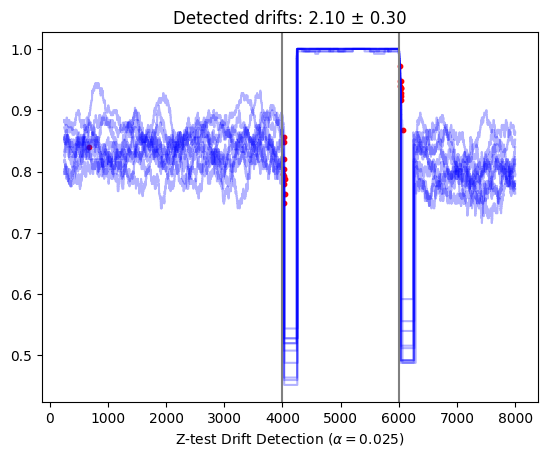

ZTestDriftDetector summary:
{'AA': 0.8704569575031504, 'ANR': 2.1, 'SNR': inf}


In [10]:
#ztest river LogisticRegression multiple seeds Sudden

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

alpha = 0.025

seeds = np.arange(42, 142, 10)
z_accuracy_2 = []
z_detected_2 = []
for seed in seeds:
    stream = stream_factory_sudden(seed)
    model = LogisticRegressionClassifier()
    detector = ZTestDriftDetector(alpha)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    z_accuracy_2.append(acc)
    z_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, z_accuracy_2, z_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (z-test) ----

# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_sudden(seeds[0]).drift_points

z_summary = summarize_runs(
    accuracies=z_accuracy_2,
    detected_drifts_list=z_detected_2,
    drift_points=drift_points,
    tol=n
)

print("ZTestDriftDetector summary:")
print(z_summary)

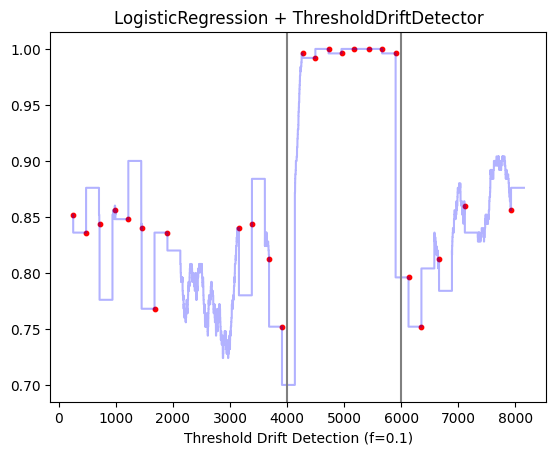

In [11]:
# Threshold-based detector with River LogisticRegression

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000
seed = 42


detector_thr = ThresholdDriftDetector(f)
stream2 = stream_factory_sudden(seed)   # new stream instance

model = LogisticRegressionClassifier()
accuracy_thr, drifts_thr = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream2,
    detector=detector_thr,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_thr], [drifts_thr], stream2, detector_thr)
ax.set_title("LogisticRegression + ThresholdDriftDetector")
plt.show()

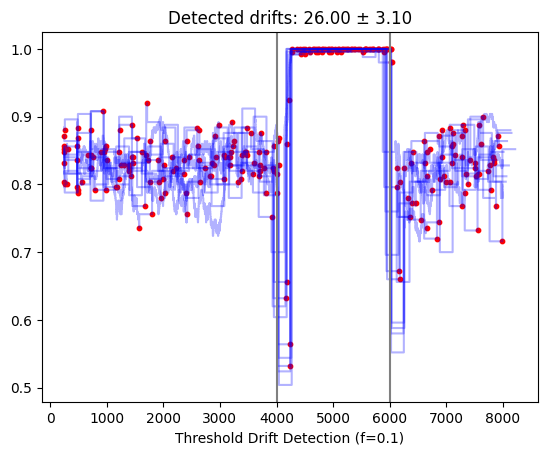

ThresholdDriftDetector summary:
{'AA': 0.8501730164905539, 'ANR': 26.0, 'SNR': 0.17342258131731816}


In [12]:
#threshold river logistiRegression multiple seeds sudden drift

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

seeds = np.arange(42, 142, 10)
thr_accuracy_2 = []
thr_detected_2 = []
for seed in seeds:
    stream = stream_factory_sudden(seed)
    model = LogisticRegressionClassifier()
    detector = ThresholdDriftDetector(f)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    thr_accuracy_2.append(acc)
    thr_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, thr_accuracy_2, thr_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (threshold) ----
# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_sudden(seeds[0]).drift_points

thr_summary = summarize_runs(
    accuracies=thr_accuracy_2,
    detected_drifts_list=thr_detected_2,
    drift_points=drift_points,
    tol=n
)
print("ThresholdDriftDetector summary:")
print(thr_summary)

Sklearn MLP - Gradual Drift

In [ ]:
# MLP experiment Gradual
# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

# Choose which stream scenario you want to test
seed = 42
stream = stream_factory_2_new(seed)   # or stream_factory(seed), stream_factory_3(seed), etc.

# Use river.naive_bayes.GaussianNB via our adapter
model =SklearnMLPClassifier()

# Pick a detector – for example, Z-test
alpha = 0.025
detector = ZTestDriftDetector(alpha)

accuracy_pac, detected_drifts_pac = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream,
    detector=detector,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_pac], [detected_drifts_pac], stream, detector)
ax.set_title("MLP + ZTestDriftDetector")
plt.show()

: 

In [ ]:
#ztest sklearn MLP multiple seeds

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

alpha = 0.025

seeds = np.arange(42, 142, 10)
z_accuracy_2 = []
z_detected_2 = []
for seed in seeds:
    stream = stream_factory_2_new(seed)
    model = SklearnMLPClassifier()
    detector = ZTestDriftDetector(alpha)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    z_accuracy_2.append(acc)
    z_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, z_accuracy_2, z_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (z-test) ----

# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_2_new(seeds[0]).drift_points

z_summary = summarize_runs(
    accuracies=z_accuracy_2,
    detected_drifts_list=z_detected_2,
    drift_points=drift_points,
    tol=n
)

print("ZTestDriftDetector summary:")
print(z_summary)

In [ ]:
# Threshold-based detector with sklearn MLP

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000
seed = 42


detector_thr = ThresholdDriftDetector(f)
stream2 = stream_factory_2_new(seed)   # new stream instance

model = SklearnMLPClassifier()
accuracy_thr, drifts_thr = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream2,
    detector=detector_thr,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_thr], [drifts_thr], stream2, detector_thr)
ax.set_title("MLP + ThresholdDriftDetector")
plt.show()


In [ ]:
#threshold sklearn MLP multiple seeds

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

seeds = np.arange(42, 142, 10)
thr_accuracy_2 = []
thr_detected_2 = []
for seed in seeds:
    stream = stream_factory_2_new(seed)
    model = SklearnMLPClassifier()
    detector = ThresholdDriftDetector(f)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    thr_accuracy_2.append(acc)
    thr_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, thr_accuracy_2, thr_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (threshold) ----
# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_2_new(seeds[0]).drift_points

thr_summary = summarize_runs(
    accuracies=thr_accuracy_2,
    detected_drifts_list=thr_detected_2,
    drift_points=drift_points,
    tol=n
)
print("ThresholdDriftDetector summary:")
print(thr_summary)


Sklearn MLP - Sudden Drift

In [ ]:
#Ztest Sudden 
# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

# Choose which stream scenario you want to test
seed = 42
stream = stream_factory_sudden(seed)   # or stream_factory(seed), stream_factory_3(seed), etc.

# Use via our adapter
model = SklearnMLPClassifier()

# Pick a detector – for example, Z-test
alpha = 0.025
detector = ZTestDriftDetector(alpha)

accuracy_gnb, detected_drifts_gnb = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream,
    detector=detector,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_gnb], [detected_drifts_gnb], stream, detector)
ax.set_title("MLP + ZTestDriftDetector")
plt.show()

In [ ]:
#ztest sklearn MLP multiple seeds Sudden

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

alpha = 0.025

seeds = np.arange(42, 142, 10)
z_accuracy_2 = []
z_detected_2 = []
for seed in seeds:
    stream = stream_factory_sudden(seed)
    model = SklearnMLPClassifier()
    detector = ZTestDriftDetector(alpha)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    z_accuracy_2.append(acc)
    z_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, z_accuracy_2, z_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (z-test) ----

# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_sudden(seeds[0]).drift_points

z_summary = summarize_runs(
    accuracies=z_accuracy_2,
    detected_drifts_list=z_detected_2,
    drift_points=drift_points,
    tol=n
)

print("ZTestDriftDetector summary:")
print(z_summary)

In [ ]:
# Threshold-based detector with sklearn MLP

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000
seed = 42


detector_thr = ThresholdDriftDetector(f)
stream2 = stream_factory_sudden(seed)   # new stream instance

model = SklearnMLPClassifier()
accuracy_thr, drifts_thr = experiment(
    n=n,
    nu=nu,
    gamma=gamma,
    max_t=max_t,
    stream=stream2,
    detector=detector_thr,
    model=model,
)

fig, ax = plt.subplots()
generate_figure(ax, [accuracy_thr], [drifts_thr], stream2, detector_thr)
ax.set_title("MLP + ThresholdDriftDetector")
plt.show()

In [ ]:
#threshold sklearn MLP multiple seeds sudden drift

# Parameters (reuse same as before)
n = 250     # window size
f = 0.1     # outlier fraction threshold
nu = 0.1    # OCC parameter
gamma = 0.5 # OCC parameter (for OCC, unchanged)
max_t = 8_000

seeds = np.arange(42, 142, 10)
thr_accuracy_2 = []
thr_detected_2 = []
for seed in seeds:
    stream = stream_factory_sudden(seed)
    model = SklearnMLPClassifier()
    detector = ThresholdDriftDetector(f)
    acc, drifts = experiment(n, nu, gamma, max_t, stream, detector, model)
    thr_accuracy_2.append(acc)
    thr_detected_2.append(drifts)

fig, ax = plt.subplots()
generate_figure(ax, thr_accuracy_2, thr_detected_2, stream, detector)
plt.show()

# ---- Metrics summary (threshold) ----
# get drift_points once (seed doesn't matter for drift schedule)
drift_points = stream_factory_sudden(seeds[0]).drift_points

thr_summary = summarize_runs(
    accuracies=thr_accuracy_2,
    detected_drifts_list=thr_detected_2,
    drift_points=drift_points,
    tol=n
)
print("ThresholdDriftDetector summary:")
print(thr_summary)